# Analiza hantavirusa primenom metoda istraživanja podataka
## Tema 1, Zadatak 1.2 — Klasterovanje nad karakteristikama ponavljajućih sekvenci

Za četiri vrste hantavirusa (Hantaan, Dobrava-Belgrade, Puumala, Sin Nombre) analiziraju se
ponavljajuće sekvence (repeats) u aminokiselinskim sekvencama GPC (glycoprotein precursor) i N
(nucleocapsid protein), sa ciljem primene klasterovanja nad izvedenim karakteristikama i
poređenja dobijenih klastera sa stvarnom taksonomskom pripadnošću vrsti.

# 1. Uvod i konfiguracija

Učitavanje biblioteka, definisanje putanja i mapiranje preuzetih FASTA fajlova
(NCBI Virus baza) na (vrsta, kompletnost).

In [1]:
import re
import os
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

DATA_RAW = Path("data/raw")
DATA_FILTERED = Path("data/filtered")
REPEAT_OUTPUT_DIR = Path("repeat_output")
FIGURES_DIR = Path("figures")

DATA_FILTERED.mkdir(parents=True, exist_ok=True)
REPEAT_OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


# 1. Uvod i konfiguracija (nastavak)

Mapiranje preuzetih FASTA fajlova (NCBI Virus baza) na (vrsta, kompletnost), na osnovu
broja sekvenci po fajlu i sadržaja headera (potvrđeno ranijom inspekcijom).

In [2]:
FILE_SPECIES_MAP = {
    "hantaan_all.fasta": ("hantanense", "all"),
    "hantaan_complete.fasta": ("hantanense", "complete"),
    "dobrava_all.fasta": ("dobravaense", "all"),
    "dobrava_complete.fasta": ("dobravaense", "complete"),
    "puumala_all.fasta": ("puumalaense", "all"),
    "puumala_complete.fasta": ("puumalaense", "complete"),
    "sinnombre_all.fasta": ("sinnombreense", "all"),
    "sinnombre_complete.fasta": ("sinnombreense", "complete"),
}

for fname in FILE_SPECIES_MAP:
    path = DATA_RAW / fname
    assert path.exists(), f"Fajl ne postoji: {path}"
print("Svi fajlovi pronađeni.")


Svi fajlovi pronađeni.


# 2. Klasifikacija proteina (GPC / N)

Opisi proteina u NCBI Virus bazi nisu uniformni (tipfeleri, sinonimi, različiti stilovi
anotacije). Prvo se definiše osnovna, konzervativna klasifikacija - sekvenca se
klasifikuje kao:

- **N (nucleocapsid protein)** - opis sadrži "nucleocapsid", "nucleoprotein" ili njihove
  uobičajene tipfelere.
- **GPC (glycoprotein precursor)** - opis eksplicitno pominje ceo prekursor
  ("glycoprotein precursor", "M polyprotein", "GPC"...). Pojedinačne podjedinice
  (G1, G2, Gn, Gc) su svesno isključene jer predstavljaju kraće proteinske proizvode,
  ne ceo prekursor.

In [3]:
def classify_protein(description: str) -> str | None:
    d = description.lower().strip()

    n_keywords = ["nucleocapsid", "nucleoprotein", "nucleocapsin", "nucleocapside"]
    if any(k in d for k in n_keywords):
        return "N"

    gpc_keywords = [
        "glycoprotein precursor", "glycoprotein precusor", "glicoprotein precursor",
        "m polyprotein", "gpc", "g1/g2 glycoprotein precursor",
        "g1g2 glycoprotein precursor", "envelope polyprotein",
        "precursor structural polyprotein",
    ]
    if any(k in d for k in gpc_keywords):
        return "GPC"

    return None


DESC_RE = re.compile(r"\|(.*?)\s*\[")

def extract_description(fasta_header: str) -> str:
    """fasta_header je rec.description iz Bio.SeqIO (bez '>')."""
    m = DESC_RE.search(fasta_header)
    return m.group(1).strip() if m else ""


In [4]:
test_cases = [
    "nucleocapsid protein",
    "glycoprotein precursor",
    "envelope glycoprotein",
    "G1 glycoprotein, partial",
    "RNA-dependent RNA polymerase",
    "M polyprotein",
    "GPC",
]
for t in test_cases:
    print(t, "->", classify_protein(t))


nucleocapsid protein -> N
glycoprotein precursor -> GPC
envelope glycoprotein -> None
G1 glycoprotein, partial -> None
RNA-dependent RNA polymerase -> None
M polyprotein -> GPC
GPC -> GPC


In [5]:
from collections import Counter

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    counter = Counter()
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        counter[label] += 1
    print(f"{fname:25s} {species:15s} {completeness:9s} -> {dict(counter)}")


hantaan_all.fasta         hantanense      all       -> {'N': 695, None: 1356, 'GPC': 146}
hantaan_complete.fasta    hantanense      complete  -> {'N': 90, None: 156, 'GPC': 2}
dobrava_all.fasta         dobravaense     all       -> {None: 319, 'GPC': 145, 'N': 311}
dobrava_complete.fasta    dobravaense     complete  -> {None: 8, 'GPC': 13, 'N': 18}
puumala_all.fasta         puumalaense     all       -> {'N': 1787, None: 1549, 'GPC': 512}
puumala_complete.fasta    puumalaense     complete  -> {'N': 56, None: 64, 'GPC': 22}
sinnombre_all.fasta       sinnombreense   all       -> {None: 197, 'GPC': 125, 'N': 130}
sinnombre_complete.fasta  sinnombreense   complete  -> {None: 10, 'GPC': 3, 'N': 6}


Primetan je problem kod `hantaan_complete` - samo 2 sekvence klasifikovane kao GPC.
Sledeći korak je da se istraži šta se krije u kategoriji `None` za sve "complete" fajlove,
da se proveri da li se tu gubi nešto relevantno.

In [6]:
none_descriptions = Counter()

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    if completeness != "complete":
        continue
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        if classify_protein(desc) is None:
            none_descriptions[desc] += 1

for desc, count in none_descriptions.most_common():
    print(f"{count:4d}  {desc}")


  99  RNA-dependent RNA polymerase
  75  glycoprotein
   6  RNA polymerase
   6  glycoproteins precursor
   6  NSs
   6  RNA-dependet RNA polymerase
   5  nonstructural protein
   5  small non-structural protein
   4  RNA-directed RNA polymerase L
   3  putative RNA-dependent RNA polymerase
   3  glycoprotein polyprotein precursor
   2  G1 and G2 glycoprotein
   2  polymerase
   2  RNA-dependent RNA polymerase protein
   2  viral RNA polymerase (L protein)
   1  envelope glycoprotein G2 (see comment), partial
   1  envelope glycoprotein G1 (see comment), partial
   1  putative polymerase
   1  hypothetical protein HTNVsMgp1
   1  hypothetical protein HTNVsSgp1
   1  GP
   1  envelope glycoprotein
   1  polymerase protein
   1  RdRp
   1  L protein
   1  polyprotein
   1  putative nonstructural protein


Uočena su dva odvojena nalaza:
1. Dva keyword bag-a u trenutnoj klasifikaciji -"glycoproteins precursor" (množina) i
   "glycoprotein polyprotein precursor" (drugačiji redosled reči) nisu uhvaćeni, iako
   su nedvosmisleno GPC.
2. Najveći gubitak je opis "glycoprotein" bez ikakvog dodatka (75 sekvenci) - potrebno je
   proveriti da li se ove sekvence koncentrišu baš kod hantaan_complete (gde nedostaje GPC),
   i da li predstavljaju punu dužinu proteina ili fragmente.

In [7]:
glycoprotein_only_by_species = Counter()

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    if completeness != "complete":
        continue
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        if desc.strip().lower() == "glycoprotein":
            glycoprotein_only_by_species[species] += 1

print(glycoprotein_only_by_species)


Counter({'hantanense': 66, 'puumalaense': 6, 'sinnombreense': 3})


In [8]:
import statistics

lengths_precursor = []
lengths_bare = []

for rec in SeqIO.parse(DATA_RAW / "hantaan_complete.fasta", "fasta"):
    desc = extract_description(rec.description).strip().lower()
    if "precursor" in desc and "glycoprotein" in desc:
        lengths_precursor.append(len(rec.seq))
    elif desc == "glycoprotein":
        lengths_bare.append(len(rec.seq))

print("precursor:", lengths_precursor)
print("bare glycoprotein - broj:", len(lengths_bare))
print("bare glycoprotein - min/max/mean:", min(lengths_bare), max(lengths_bare), statistics.mean(lengths_bare))


precursor: []
bare glycoprotein - broj: 66
bare glycoprotein - min/max/mean: 1135 1135 1135


In [9]:
lengths_confirmed_gpc = []

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description).strip().lower()
        if "precursor" in desc and "glycoprotein" in desc:
            lengths_confirmed_gpc.append((species, len(rec.seq)))

from collections import defaultdict
by_species = defaultdict(list)
for sp, l in lengths_confirmed_gpc:
    by_species[sp].append(l)

for sp, ls in by_species.items():
    print(sp, "n=", len(ls), "min/max:", min(ls), max(ls))


hantanense n= 127 min/max: 89 1135
dobravaense n= 150 min/max: 61 1135
puumalaense n= 506 min/max: 69 1148
sinnombreense n= 114 min/max: 67 1140


**Zaključak:** maksimalne dužine potvrđenih GPC precursor sekvenci (1135–1148 AK, u
zavisnosti od vrste) poklapaju se sa dužinom "golih" `glycoprotein` opisa (1135 AK kod
hantanense). Ovo potvrđuje da je "goli" opis zapravo pun GPC precursor, samo generičnije
anotiran - treba ga uključiti u GPC klasu, ali uz proveru dužine (jer minimalne vrednosti
kod "precursor" opisa, 61–89 AK, pokazuju da i eksplicitno označeni "precursor" zapisi mogu
biti parcijalni fragmenti). Provera dužine se uvodi u sledećoj sekciji.

Pre toga, treba proveriti da li se ovaj obrazac (goli opis = puna dužina) drži i kod ostalih
vrsta gde se "goli" `glycoprotein` opis javlja (puumalaense, sinnombreense).

In [10]:
from collections import defaultdict

glycoprotein_counts = defaultdict(int)

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description).strip().lower()
        if desc == "glycoprotein":
            glycoprotein_counts[species] += 1

for species, count in glycoprotein_counts.items():
    print(f"{species}: {count} glycoprotein sequences")

hantanense: 340 glycoprotein sequences
puumalaense: 22 glycoprotein sequences
sinnombreense: 27 glycoprotein sequences


**Zaključak istraživanja:**
1. Dva keyword baga treba popraviti: "glycoproteins precursor" i "glycoprotein polyprotein precursor".
2. "Goli" opis `glycoprotein` treba uključiti u GPC klasu.
3. Ni tekst opisa ("precursor", "partial") ni sam po sebi nisu pouzdan pokazatelj pune
   dužine sekvence (postoje kratki fragmenti bez reči "partial" u opisu, npr. sinnombreense
   990/985/550 AK). Zato je neophodan nezavisan filter na osnovu stvarne dužine sekvence,
   koji se uvodi u Sekciji 3.

Na osnovu ovoga, finalizuje se `classify_protein()` funkcija.

In [11]:
def classify_protein(description: str) -> str | None:
    d = description.lower().strip()

    n_keywords = ["nucleocapsid", "nucleoprotein", "nucleocapsin", "nucleocapside"]
    if any(k in d for k in n_keywords):
        return "N"

    gpc_keywords = [
        "glycoprotein precursor", "glycoprotein precusor", "glicoprotein precursor",
        "glycoproteins precursor", "glycoprotein polyprotein precursor",
        "m polyprotein", "gpc", "g1/g2 glycoprotein precursor",
        "g1g2 glycoprotein precursor", "envelope polyprotein",
        "precursor structural polyprotein",
    ]
    if any(k in d for k in gpc_keywords):
        return "GPC"

    # "goli" opis "glycoprotein" - dokazano da odgovara punoj duzini GPC-a
    # (vidi istrazivanje iznad); puna duzina se dodatno proverava u Sekciji 3
    if d == "glycoprotein":
        return "GPC"

    return None


# 3. Filter dužine sekvence

Klasifikacija po opisu nije dovoljna sama po sebi - pokazano je da opis ne pominje uvek
pouzdano da li je sekvenca puna ili parcijalna. Sledeći korak je provera distribucije
dužina po tipu proteina, da se utvrde razumni pragovi za filtriranje fragmenata.

In [12]:
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    counter = Counter()
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        counter[label] += 1
    print(f"{fname:25s} {species:15s} {completeness:9s} -> {dict(counter)}")


hantaan_all.fasta         hantanense      all       -> {'N': 695, None: 1081, 'GPC': 421}
hantaan_complete.fasta    hantanense      complete  -> {'N': 90, 'GPC': 68, None: 90}
dobrava_all.fasta         dobravaense     all       -> {None: 318, 'GPC': 146, 'N': 311}
dobrava_complete.fasta    dobravaense     complete  -> {None: 8, 'GPC': 13, 'N': 18}
puumala_all.fasta         puumalaense     all       -> {'N': 1787, None: 1520, 'GPC': 541}
puumala_complete.fasta    puumalaense     complete  -> {'N': 56, None: 49, 'GPC': 37}
sinnombre_all.fasta       sinnombreense   all       -> {None: 173, 'GPC': 149, 'N': 130}
sinnombre_complete.fasta  sinnombreense   complete  -> {None: 7, 'GPC': 6, 'N': 6}


Sada se proverava distribucija dužina sekvenci po tipu proteina, na osnovu ove
(proširene) klasifikacije, da bi se utvrdili razumni pragovi za filtriranje fragmenata.

          count        mean         std   min     5%    25%    50%     75%  \
protein                                                                      
GPC      1381.0  657.797248  469.636675  53.0   91.0  190.0  484.0  1135.0   
N        3093.0  307.078565  132.759268  34.0  100.0  177.0  336.0   429.0   

            95%     max  
protein                  
GPC      1148.0  1149.0  
N         433.0  1140.0  


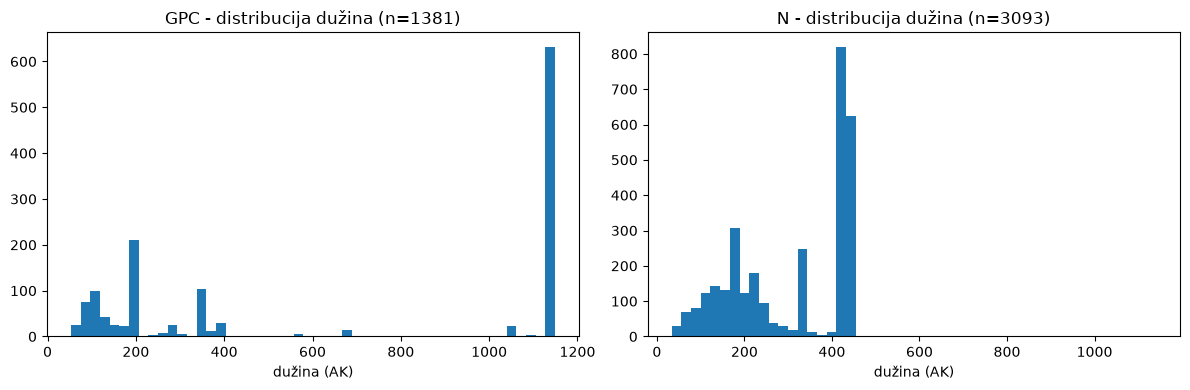

In [13]:
rows = []
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        if label is not None:
            rows.append({"species": species, "completeness": completeness,
                         "protein": label, "length": len(rec.seq)})

length_check_df = pd.DataFrame(rows)
print(length_check_df.groupby("protein")["length"].describe(percentiles=[.05, .25, .5, .75, .95]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, protein in zip(axes, ["GPC", "N"]):
    subset = length_check_df[length_check_df.protein == protein]["length"]
    ax.hist(subset, bins=50)
    ax.set_title(f"{protein} - distribucija dužina (n={len(subset)})")
    ax.set_xlabel("dužina (AK)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "duzina_distribucija.png", dpi=150, bbox_inches="tight")
plt.show()


Na osnovu grafika, pragovi su izabrani na sledeći način:

- **GPC**: donja granica 1000 AK (glavni pik je na ~1130–1150, prazan prostor je između
  ~400 i ~1000, pa svaka vrednost u tom rasponu daje isti rezultat).
- **N**: donji prag 400 AK (glavni pik na ~420–440).

In [14]:
LENGTH_THRESHOLDS = {"GPC": 1000, "N": 400}

def is_full_length(protein_label: str, seq_length: int) -> bool:
    return seq_length >= LENGTH_THRESHOLDS[protein_label]


In [15]:
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    counter = Counter()
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        if label is not None and not is_full_length(label, len(rec.seq)):
            label = None
        counter[label] += 1
    print(f"{fname:25s} {species:15s} {completeness:9s} -> {dict(counter)}")


hantaan_all.fasta         hantanense      all       -> {'N': 524, None: 1380, 'GPC': 293}
hantaan_complete.fasta    hantanense      complete  -> {'N': 90, 'GPC': 68, None: 90}
dobrava_all.fasta         dobravaense     all       -> {None: 650, 'GPC': 35, 'N': 90}
dobrava_complete.fasta    dobravaense     complete  -> {None: 9, 'GPC': 12, 'N': 18}
puumala_all.fasta         puumalaense     all       -> {'N': 600, None: 3098, 'GPC': 150}
puumala_complete.fasta    puumalaense     complete  -> {'N': 56, None: 49, 'GPC': 37}
sinnombre_all.fasta       sinnombreense   all       -> {None: 323, 'GPC': 62, 'N': 67}
sinnombre_complete.fasta  sinnombreense   complete  -> {None: 7, 'GPC': 6, 'N': 6}


# 4. Filtriranje i čuvanje FASTA fajlova

Kombinuju se sva tri filtera: klasifikacija proteina, provera pune dužine, i uklanjanje
sekvenci sa dvosmislenim karakterima (ambiguous characters = 0, kako zahteva uputstvo
zadatka). Za svaku kombinaciju (vrsta, kompletnost, protein) čuva se poseban FASTA fajl.

In [16]:
def filter_and_save():
    summary = []

    for fname, (species, completeness) in FILE_SPECIES_MAP.items():
        buckets = {"N": [], "GPC": []}

        for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
            desc = extract_description(rec.description)
            label = classify_protein(desc)

            if label is None:
                continue
            if not is_full_length(label, len(rec.seq)):
                continue

            seq_str = str(rec.seq).replace("*", "")
            standard_aa = set("ACDEFGHIKLMNPQRSTVWY")
            if any(ch.upper() not in standard_aa for ch in seq_str):
                continue  # ambiguous characters - iskljucujemo (uputstvo zadatka)

            buckets[label].append(rec)

        for protein, records in buckets.items():
            out_path = DATA_FILTERED / f"{species}_{completeness}_{protein}.fasta"
            SeqIO.write(records, out_path, "fasta")
            summary.append({
                "species": species, "completeness": completeness,
                "protein": protein, "n_sequences": len(records),
            })

    return pd.DataFrame(summary)


summary_df = filter_and_save()
summary_df


,species,completeness,protein,n_sequences
0,hantanense,all,N,522
1,hantanense,all,GPC,292
2,hantanense,complete,N,90
3,hantanense,complete,GPC,67
4,dobravaense,all,N,90
5,dobravaense,all,GPC,31
6,dobravaense,complete,N,18
7,dobravaense,complete,GPC,11
8,puumalaense,all,N,577
9,puumalaense,all,GPC,135


# 5. Pokretanje RepeatsPlus/StatRepeats alata

Alat `StatRepeatsNoDB` (RepeatsPlus paket, Bioinformatics Research Group, Matematički
fakultet Beograd) pokreće se nad svakim od 16 filtriranih FASTA fajlova, tražeći tačna
(exact) ponavljanja motiva minimalne dužine 3 aminokiseline (parametar izabran na osnovu
preporuke samog alata - za alfabet od 20 aminokiselina, dužina motiva 2 je statistički
premala da bi rezultati bili pouzdani).

In [17]:
REPEATS_TOOL = Path("repeats_tool/Programs/StatRepeats/Linux/StatRepeatsNoDB").resolve()
TOOL_DIR = REPEATS_TOOL.parent
FRAGMENT_LENGTH = 3


def run_statrepeats(fasta_path: Path, output_path: Path):
    # putanje se prosledjuju kao relativne (u odnosu na cwd=TOOL_DIR) jer alat
    # pogresno tumaci apsolutne putanje koje pocinju "/" kao opcije komandne linije
    fasta_rel = os.path.relpath(fasta_path.resolve(), start=TOOL_DIR)
    output_rel = os.path.relpath(output_path.resolve(), start=TOOL_DIR)

    result = subprocess.run(
        [str(REPEATS_TOOL), fasta_rel, str(FRAGMENT_LENGTH),
         "-protein", "-output", output_rel],
        capture_output=True, text=True, cwd=TOOL_DIR,
    )
    return result


In [18]:
results_log = []

for fasta_path in sorted(DATA_FILTERED.glob("*.fasta")):
    output_path = REPEAT_OUTPUT_DIR / f"{fasta_path.stem}.txt"
    result = run_statrepeats(fasta_path, output_path)
    results_log.append({
        "file": fasta_path.name,
        "returncode": result.returncode,
        "output_exists": output_path.exists(),
        "output_size": output_path.stat().st_size if output_path.exists() else 0,
    })
    print(f"{fasta_path.name:40s} rc={result.returncode}  "
          f"out_size={results_log[-1]['output_size']}")

log_df = pd.DataFrame(results_log)
log_df


dobravaense_all_GPC.fasta                rc=0  out_size=119570
dobravaense_all_N.fasta                  rc=0  out_size=16957
dobravaense_complete_GPC.fasta           rc=0  out_size=42887
dobravaense_complete_N.fasta             rc=0  out_size=3543
hantanense_all_GPC.fasta                 rc=0  out_size=550973
hantanense_all_N.fasta                   rc=0  out_size=52299
hantanense_complete_GPC.fasta            rc=0  out_size=117617
hantanense_complete_N.fasta              rc=0  out_size=9080
puumalaense_all_GPC.fasta                rc=0  out_size=712778
puumalaense_all_N.fasta                  rc=0  out_size=365277
puumalaense_complete_GPC.fasta           rc=0  out_size=201106
puumalaense_complete_N.fasta             rc=0  out_size=28889
sinnombreense_all_GPC.fasta              rc=0  out_size=108043
sinnombreense_all_N.fasta                rc=0  out_size=20791
sinnombreense_complete_GPC.fasta         rc=0  out_size=15863
sinnombreense_complete_N.fasta           rc=0  out_size=2615


,file,returncode,output_exists,output_size
0,dobravaense_all_GPC.fasta,0,True,119570
1,dobravaense_all_N.fasta,0,True,16957
2,dobravaense_complete_GPC.fasta,0,True,42887
3,dobravaense_complete_N.fasta,0,True,3543
4,hantanense_all_GPC.fasta,0,True,550973
5,hantanense_all_N.fasta,0,True,52299
6,hantanense_complete_GPC.fasta,0,True,117617
7,hantanense_complete_N.fasta,0,True,9080
8,puumalaense_all_GPC.fasta,0,True,712778
9,puumalaense_all_N.fasta,0,True,365277


# 6. Parsiranje izlaza i feature ekstrakcija

Izlaz alata sadrži, za svaku sekvencu, agregatnu statistiku broja pronađenih ponavljanja
po dužini motiva (linije oblika `Total for length X is Y.`). Ove vrednosti se parsiraju
u feature tabelu - jedan red po sekvenci. Dodatno se uključuje i dužina sekvence, kao i
normalizovane verzije karakteristika (broj ponavljanja / dužina sekvence), kako bi se
razdvojio efekat same dužine sekvence od "gustine" ponavljanja.

In [19]:
BLOCK_START_RE = re.compile(r"^(\S+) Alphabet size is (\d+)\.")
TOTAL_RE = re.compile(r"^Total for length (\d+) is (\d+)\.")


def parse_statrepeats_output(filepath: Path) -> dict[str, dict[int, int]]:
    """Vraca {seq_id: {duzina_motiva: broj_ponavljanja}}"""
    results = {}
    current_id = None

    with open(filepath) as f:
        for line in f:
            m_start = BLOCK_START_RE.match(line)
            if m_start:
                current_id = m_start.group(1)
                results[current_id] = {}
                continue

            m_total = TOTAL_RE.match(line)
            if m_total and current_id is not None:
                length = int(m_total.group(1))
                count = int(m_total.group(2))
                results[current_id][length] = count

    return results


test_result = parse_statrepeats_output(REPEAT_OUTPUT_DIR / "hantanense_complete_GPC.txt")
print("broj sekvenci:", len(test_result))
print(list(test_result.items())[:5])


broj sekvenci: 67
[('XHP16135.1', {3: 14, 4: 7}), ('XHP16134.1', {3: 14, 4: 7}), ('XHP16133.1', {3: 14, 4: 7}), ('XHP16132.1', {3: 14, 4: 7}), ('XHP16131.1', {3: 14, 4: 7})]


In [20]:
def build_feature_table():
    rows = []
    for txt_path in sorted(REPEAT_OUTPUT_DIR.glob("*.txt")):
        species, completeness, protein = txt_path.stem.rsplit("_", 2)
        parsed = parse_statrepeats_output(txt_path)

        for seq_id, length_counts in parsed.items():
            row = {"accession": seq_id, "species": species,
                   "completeness": completeness, "protein": protein}
            for length, count in length_counts.items():
                row[f"repeats_len_{length}"] = count
            rows.append(row)

    df = pd.DataFrame(rows)
    repeat_cols = [c for c in df.columns if c.startswith("repeats_len_")]
    df[repeat_cols] = df[repeat_cols].fillna(0).astype(int)
    return df


def add_sequence_length(df):
    lengths = {}
    for fasta_path in DATA_FILTERED.glob("*.fasta"):
        for rec in SeqIO.parse(fasta_path, "fasta"):
            lengths[rec.id] = len(rec.seq)
    df = df.copy()
    df["seq_length"] = df["accession"].map(lengths)
    return df


def add_normalized_features(df):
    df = df.copy()
    repeat_cols = [c for c in df.columns if c.startswith("repeats_len_")]
    for col in repeat_cols:
        df[f"{col}_norm"] = df[col] / df["seq_length"]
    return df


feature_df = build_feature_table()
feature_df = add_sequence_length(feature_df)
feature_df = add_normalized_features(feature_df)

print(feature_df.shape)
feature_df.head()


(2034, 15)


,accession,species,completeness,protein,repeats_len_3,repeats_len_4,repeats_len_6,repeats_len_5,repeats_len_8,seq_length,repeats_len_3_norm,repeats_len_4_norm,repeats_len_6_norm,repeats_len_5_norm,repeats_len_8_norm
0,YFI28168.1,dobravaense,all,GPC,96,10,0,0,0,1135,0.084581,0.008811,0.0,0.0,0.0
1,YFI28166.1,dobravaense,all,GPC,95,10,0,0,0,1135,0.083700,0.008811,0.0,0.0,0.0
2,UVB78522.1,dobravaense,all,GPC,99,0,0,0,0,1135,0.087225,0.000000,0.0,0.0,0.0
3,UVB78521.1,dobravaense,all,GPC,102,0,0,0,0,1135,0.089868,0.000000,0.0,0.0,0.0
4,UTK64190.1,dobravaense,all,GPC,87,0,0,0,0,1095,0.079452,0.000000,0.0,0.0,0.0


# 7. Priprema podataka za klasterovanje

Analiza se radi **odvojeno** za svaku kombinaciju (protein, kompletnost) - GPC i N imaju
različite biološke funkcije i drastično različite dužine, pa njihovo mešanje u isti
feature prostor bi otežalo tumačenje rezultata.

In [21]:
FEATURE_COLS = [c for c in feature_df.columns
                if c.startswith("repeats_len_") or c == "seq_length"]
FEATURE_COLS


['repeats_len_3',
 'repeats_len_4',
 'repeats_len_6',
 'repeats_len_5',
 'repeats_len_8',
 'seq_length',
 'repeats_len_3_norm',
 'repeats_len_4_norm',
 'repeats_len_6_norm',
 'repeats_len_5_norm',
 'repeats_len_8_norm']

In [22]:
def prepare_subset(df, protein, completeness, feature_cols=FEATURE_COLS):
    subset = df[(df.protein == protein) & (df.completeness == completeness)].copy()
    subset = subset.dropna(subset=feature_cols)

    X = subset[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return subset, X_scaled


subset_gpc_complete, X_gpc_complete = prepare_subset(feature_df, "GPC", "complete")
print(subset_gpc_complete.shape, X_gpc_complete.shape)
print(subset_gpc_complete["species"].value_counts())


(121, 15) (121, 11)
species
hantanense       67
puumalaense      37
dobravaense      11
sinnombreense     6
Name: count, dtype: int64


Nakon standardizacije, primenjuje se PCA radi redukcije dimenzionalnosti - zadržava se
onoliko komponenti koliko pokriva ≥90% varijanse.

In [23]:
def apply_pca(X_scaled, n_components=None, variance_threshold=0.90):
    if n_components is None:
        pca_full = PCA()
        pca_full.fit(X_scaled)
        cum_var = pca_full.explained_variance_ratio_.cumsum()
        n_components = (cum_var < variance_threshold).sum() + 1

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca


X_pca_gpc_complete, pca_model = apply_pca(X_gpc_complete)
print("broj komponenti:", X_pca_gpc_complete.shape[1])
print("objasnjena varijansa:", pca_model.explained_variance_ratio_)
print("kumulativno:", pca_model.explained_variance_ratio_.cumsum())


broj komponenti: 4
objasnjena varijansa: [0.44967182 0.23111236 0.2178489  0.07900301]
kumulativno: [0.44967182 0.68078418 0.89863308 0.9776361 ]


# 8. Klasterovanje

Prvo se testira osnovna verzija sa tri algoritma sa fiksnim brojem klastera k=4
(KMeans, Agglomerative, Gaussian Mixture Model).

In [24]:
def run_clustering(X_pca, k=4):
    results = {}
    results["KMeans"] = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_pca)
    results["Agglomerative"] = AgglomerativeClustering(
        n_clusters=k, linkage="ward"
    ).fit_predict(X_pca)
    results["GaussianMixture"] = GaussianMixture(
        n_components=k, random_state=42, n_init=5
    ).fit_predict(X_pca)
    return results


cluster_results = run_clustering(X_pca_gpc_complete)
for name, labels in cluster_results.items():
    print(name, "->", pd.Series(labels).value_counts().to_dict())


KMeans -> {0: 68, 1: 31, 3: 21, 2: 1}
Agglomerative -> {1: 67, 0: 41, 3: 12, 2: 1}
GaussianMixture -> {0: 51, 1: 39, 2: 30, 3: 1}


Sva tri algoritma izdvajaju jedan klaster sa samo 1 tačkom - nije slučajnost, verovatno
postoji jedan outlier u podacima. Sledeći korak je da se pronađe ta tačka i istraži zašto
je toliko različita od ostalih.

In [25]:
subset_gpc_complete["kmeans_label"] = cluster_results["KMeans"]
subset_gpc_complete[subset_gpc_complete["kmeans_label"] == 2]


,accession,species,completeness,protein,repeats_len_3,repeats_len_4,repeats_len_6,repeats_len_5,repeats_len_8,seq_length,repeats_len_3_norm,repeats_len_4_norm,repeats_len_6_norm,repeats_len_5_norm,repeats_len_8_norm,kmeans_label
971,XHP16128.1,hantanense,complete,GPC,14,8,1,0,0,1135,0.012335,0.007048,0.000881,0.0,0.0,2


Sekvenca `XHP16128.1` ima `repeats_len_6 = 1`, dok su ostale karakteristike sasvim
tipične. Sumnja je da je ta kolona gotovo uvek 0 kod ostalih sekvenci — provera:

In [26]:
subset_gpc_complete["repeats_len_6"].value_counts()


repeats_len_6
0    120
1      1
Name: count, dtype: int64

**Objašnjenje:** kad 120 od 121 sekvenci ima vrednost 0 za `repeats_len_6`, standardna
devijacija te kolone je vrlo mala, pa čak i jedna vrednost 1 posle standardizacije postaje
ekstremno velik z-score (deljenje malim brojem eksplodira). To dovoljno pomeri tačku u PCA
prostoru da postane usamljeni "klaster za sebe" - nije stvarna biološka struktura, već
artefakt standardizacije na retkoj koloni.

**Rešenje:** pre standardizacije, iz svakog podskupa se uklanjaju karakteristike koje su
gotovo uvek nula (< 10% sekvenci ima nenultu vrednost). Prag je primenjen dosledno na svim
podskupovima (protein × kompletnost), ali pošto se retkoća razlikuje po skupu, i skup
izbačenih kolona će se razlikovati (npr. u većim "all" skupovima neke od ovih kolona mogu
biti dovoljno česte da ostanu).

In [27]:
def prepare_subset(df, protein, completeness, feature_cols=FEATURE_COLS,
                    min_nonzero_pct=10.0):
    subset = df[(df.protein == protein) & (df.completeness == completeness)].copy()
    subset = subset.dropna(subset=feature_cols)

    usable_cols, dropped_cols = [], []
    for col in feature_cols:
        nonzero_pct = (subset[col] != 0).mean() * 100
        (usable_cols if nonzero_pct >= min_nonzero_pct else dropped_cols).append(col)

    if dropped_cols:
        print(f"[{protein}/{completeness}] Izbacene retke kolone "
              f"(<{min_nonzero_pct}% nenula): {dropped_cols}")

    X = subset[usable_cols].values
    X_scaled = StandardScaler().fit_transform(X)
    return subset, X_scaled, usable_cols


subset_gpc_complete, X_gpc_complete, used_cols = prepare_subset(feature_df, "GPC", "complete")
print(subset_gpc_complete.shape, X_gpc_complete.shape)
print("koriscene kolone:", used_cols)


[GPC/complete] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_8_norm']
(121, 15) (121, 7)
koriscene kolone: ['repeats_len_3', 'repeats_len_4', 'repeats_len_5', 'seq_length', 'repeats_len_3_norm', 'repeats_len_4_norm', 'repeats_len_5_norm']


In [28]:
X_pca_gpc_complete, pca_model = apply_pca(X_gpc_complete)
print("broj komponenti:", X_pca_gpc_complete.shape[1])
print("kumulativna varijansa:", pca_model.explained_variance_ratio_.cumsum())

cluster_results = run_clustering(X_pca_gpc_complete)
for name, labels in cluster_results.items():
    print(name, "->", pd.Series(labels).value_counts().to_dict())


broj komponenti: 3
kumulativna varijansa: [0.57301517 0.86951301 0.97112364]
KMeans -> {0: 63, 1: 31, 3: 15, 2: 12}
Agglomerative -> {0: 68, 1: 25, 3: 16, 2: 12}
GaussianMixture -> {0: 63, 1: 31, 3: 15, 2: 12}


Dodaju se još dva algoritma: DBSCAN (gustinski pristup, ne zahteva unapred zadat broj
klastera) i Spectral Clustering (graf-bazirani pristup)

Za DBSCAN je potrebno odrediti parametar `eps`. Prvo se probava automatska heuristika
zasnovana na "kolenu" k-distance grafika.

In [29]:
def estimate_dbscan_eps(X, k=4):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nn.kneighbors(X)
    kth = np.sort(dists[:, -1])
    diffs = np.diff(kth)
    return kth[np.argmax(diffs)] if len(diffs) > 2 else np.median(kth)


def run_clustering(X_pca, k=4):
    results = {}
    results["KMeans"] = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_pca)
    results["Agglomerative"] = AgglomerativeClustering(
        n_clusters=k, linkage="ward"
    ).fit_predict(X_pca)
    results["GaussianMixture"] = GaussianMixture(
        n_components=k, random_state=42, n_init=5
    ).fit_predict(X_pca)

    eps = estimate_dbscan_eps(X_pca, k=4)
    results["DBSCAN"] = DBSCAN(eps=eps, min_samples=5).fit_predict(X_pca)

    results["Spectral"] = SpectralClustering(
        n_clusters=k, affinity="nearest_neighbors", random_state=42
    ).fit_predict(X_pca)

    return results


cluster_results = run_clustering(X_pca_gpc_complete)
for name, labels in cluster_results.items():
    print(name, "->", pd.Series(labels).value_counts().to_dict())


KMeans -> {0: 63, 1: 31, 3: 15, 2: 12}
Agglomerative -> {0: 68, 1: 25, 3: 16, 2: 12}
GaussianMixture -> {0: 63, 1: 31, 3: 15, 2: 12}
DBSCAN -> {2: 45, 1: 18, 6: 15, 7: 10, 0: 9, 4: 7, 3: 6, 5: 5, 8: 5, -1: 1}
Spectral -> {0: 72, 1: 23, 3: 16, 2: 10}


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Automatska heuristika daje previše sitnih klastera za DBSCAN. Potrebno je vizuelno
proceniti k-distance graf.

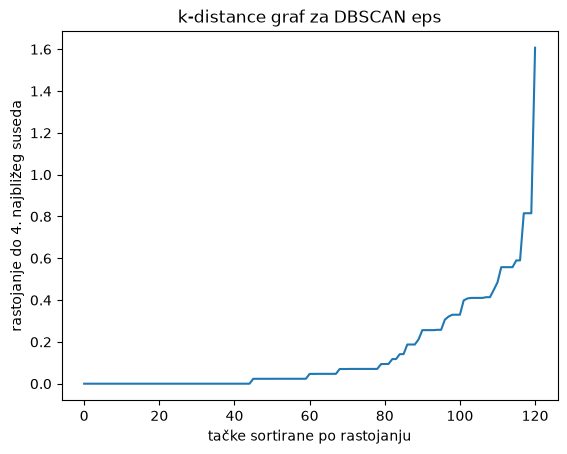

In [30]:
nn = NearestNeighbors(n_neighbors=4).fit(X_pca_gpc_complete)
dists, _ = nn.kneighbors(X_pca_gpc_complete)
kth = np.sort(dists[:, -1])

plt.plot(kth)
plt.xlabel("tačke sortirane po rastojanju")
plt.ylabel("rastojanje do 4. najbližeg suseda")
plt.title("k-distance graf za DBSCAN eps")
plt.show()


Kriva raste postepeno, bez jasnog "kolena". Probaju se nekoliko konkretnih vrednosti eps
da se pronađe najrazumnija konfiguracija.

In [31]:
for eps_try in [0.15, 0.25, 0.35, 0.5]:
    labels = DBSCAN(eps=eps_try, min_samples=4).fit_predict(X_pca_gpc_complete)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps_try}: {n_clusters} klastera, {n_noise} sum tacaka, "
          f"raspodela={pd.Series(labels).value_counts().to_dict()}")


eps=0.15: 8 klastera, 34 sum tacaka, raspodela={-1: 34, 3: 28, 2: 12, 4: 12, 6: 12, 0: 9, 1: 6, 5: 4, 7: 4}
eps=0.25: 8 klastera, 31 sum tacaka, raspodela={-1: 31, 3: 28, 2: 12, 4: 12, 6: 12, 0: 9, 7: 7, 1: 6, 5: 4}
eps=0.35: 10 klastera, 19 sum tacaka, raspodela={3: 28, -1: 19, 2: 12, 4: 12, 7: 12, 0: 9, 6: 7, 8: 7, 1: 6, 9: 5, 5: 4}
eps=0.5: 8 klastera, 10 sum tacaka, raspodela={2: 45, 1: 18, 5: 12, -1: 10, 6: 10, 0: 9, 3: 7, 4: 5, 7: 5}


**Zaključak:** DBSCAN dosledno pronalazi 8-10 gustih pod-grupa umesto očekivane 4 vrste,
bez obzira na vrednost eps. Ovo se tumači kao legitiman nalaz, ne kao neuspeh metode — za
razliku od KMeans, Agglomerative, GMM i Spectral (koji nameću k=4 i time po definiciji dele
podatke na 4 grupe), DBSCAN otkriva gustinsku strukturu bez pretpostavke o broju klastera.
Sugeriše se da postoji finija struktura unutar/preko vrsta — moguće specifične varijante ili
grupe skoro identičnih sekvenci.

Za finalnu analizu, usvaja se **eps=0.35** (najmanje šum tačaka: 19 od 121, razumna
raspodela veličina klastera).

In [32]:
def run_clustering(X_pca, k=4, dbscan_eps=0.35, dbscan_min_samples=4):
    results = {}
    results["KMeans"] = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_pca)
    results["Agglomerative"] = AgglomerativeClustering(
        n_clusters=k, linkage="ward"
    ).fit_predict(X_pca)
    results["GaussianMixture"] = GaussianMixture(
        n_components=k, random_state=42, n_init=5
    ).fit_predict(X_pca)
    results["DBSCAN"] = DBSCAN(
        eps=dbscan_eps, min_samples=dbscan_min_samples
    ).fit_predict(X_pca)
    results["Spectral"] = SpectralClustering(
        n_clusters=k, affinity="nearest_neighbors", random_state=42
    ).fit_predict(X_pca)
    return results


# 9. Evaluacija

Evaluacija kombinuje internu metriku (**Silhouette**) i eksterne metrike (**Adjusted Rand
Index** i **Normalized Mutual Information**), poredeći dobijene klastere sa stvarnom
vrstom.

In [33]:
def evaluate_clustering(X_pca, cluster_results, y_true_labels):
    species_to_int = {s: i for i, s in enumerate(sorted(set(y_true_labels)))}
    y_true = [species_to_int[s] for s in y_true_labels]

    rows = []
    for name, labels in cluster_results.items():
        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        sil = silhouette_score(X_pca, labels) if n_clusters_found >= 2 else float("nan")
        ari = adjusted_rand_score(y_true, labels)
        nmi = normalized_mutual_info_score(y_true, labels)
        rows.append({"algorithm": name, "n_clusters_found": n_clusters_found,
                     "silhouette": sil, "ARI": ari, "NMI": nmi})

    return pd.DataFrame(rows)


cluster_results = run_clustering(X_pca_gpc_complete)
eval_gpc_complete = evaluate_clustering(
    X_pca_gpc_complete, cluster_results, subset_gpc_complete["species"].values
)
eval_gpc_complete


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,algorithm,n_clusters_found,silhouette,ARI,NMI
0,KMeans,4,0.602830,0.580098,0.574768
1,Agglomerative,4,0.604330,0.530726,0.506511
2,GaussianMixture,4,0.602830,0.580098,0.574768
3,DBSCAN,10,0.692645,0.235858,0.485362
4,Spectral,4,0.292335,0.210910,0.248919


KMeans i GaussianMixture daju identičan ARI (0.580) i NMI (0.575) — provera:

In [34]:
adjusted_rand_score(cluster_results["KMeans"], cluster_results["GaussianMixture"])


1.0

Sada se ceo tok (priprema → PCA → klasterovanje → evaluacija) spaja u jednu funkciju i
pokreće za sve 4 kombinacije (protein × kompletnost).

In [35]:
def run_full_pipeline(df, protein, completeness):
    subset, X_scaled, used_cols = prepare_subset(df, protein, completeness)
    X_pca, pca_model = apply_pca(X_scaled)
    cluster_results = run_clustering(X_pca)
    eval_df = evaluate_clustering(X_pca, cluster_results, subset["species"].values)
    eval_df.insert(0, "completeness", completeness)
    eval_df.insert(0, "protein", protein)
    eval_df.insert(0, "n_sequences", len(subset))
    return subset, X_pca, cluster_results, eval_df


all_eval_results = []
all_subsets = {}

for protein in ["GPC", "N"]:
    for completeness in ["all", "complete"]:
        subset, X_pca, clusters, eval_df = run_full_pipeline(feature_df, protein, completeness)
        all_eval_results.append(eval_df)
        all_subsets[(protein, completeness)] = (subset, X_pca, clusters)
        print(f"Zavrseno: {protein}/{completeness}")

final_results = pd.concat(all_eval_results, ignore_index=True)
final_results


[GPC/all] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_8_norm']


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Zavrseno: GPC/all
[GPC/complete] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_8_norm']


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Zavrseno: GPC/complete
[N/all] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_5', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_5_norm', 'repeats_len_8_norm']


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Zavrseno: N/all
[N/complete] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_5', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_5_norm', 'repeats_len_8_norm']
Zavrseno: N/complete


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,n_sequences,protein,completeness,algorithm,n_clusters_found,silhouette,ARI,NMI
0,500,GPC,all,KMeans,4,0.639345,0.610387,0.523117
1,500,GPC,all,Agglomerative,4,0.608288,0.536283,0.470777
2,500,GPC,all,GaussianMixture,4,0.601509,0.616584,0.578081
3,500,GPC,all,DBSCAN,12,0.763695,0.451234,0.570265
4,500,GPC,all,Spectral,4,-0.327983,0.010778,0.139854
5,121,GPC,complete,KMeans,4,0.602830,0.580098,0.574768
6,121,GPC,complete,Agglomerative,4,0.604330,0.530726,0.506511
7,121,GPC,complete,GaussianMixture,4,0.602830,0.580098,0.574768
8,121,GPC,complete,DBSCAN,10,0.692645,0.235858,0.485362
9,121,GPC,complete,Spectral,4,0.292335,0.210910,0.248919


# 10. Vizualizacija

Za svaku kombinaciju (protein, kompletnost) prikazuje se 2D PCA projekcija - stvarna
vrsta naspram klastera dobijenih svakim od 5 algoritama.

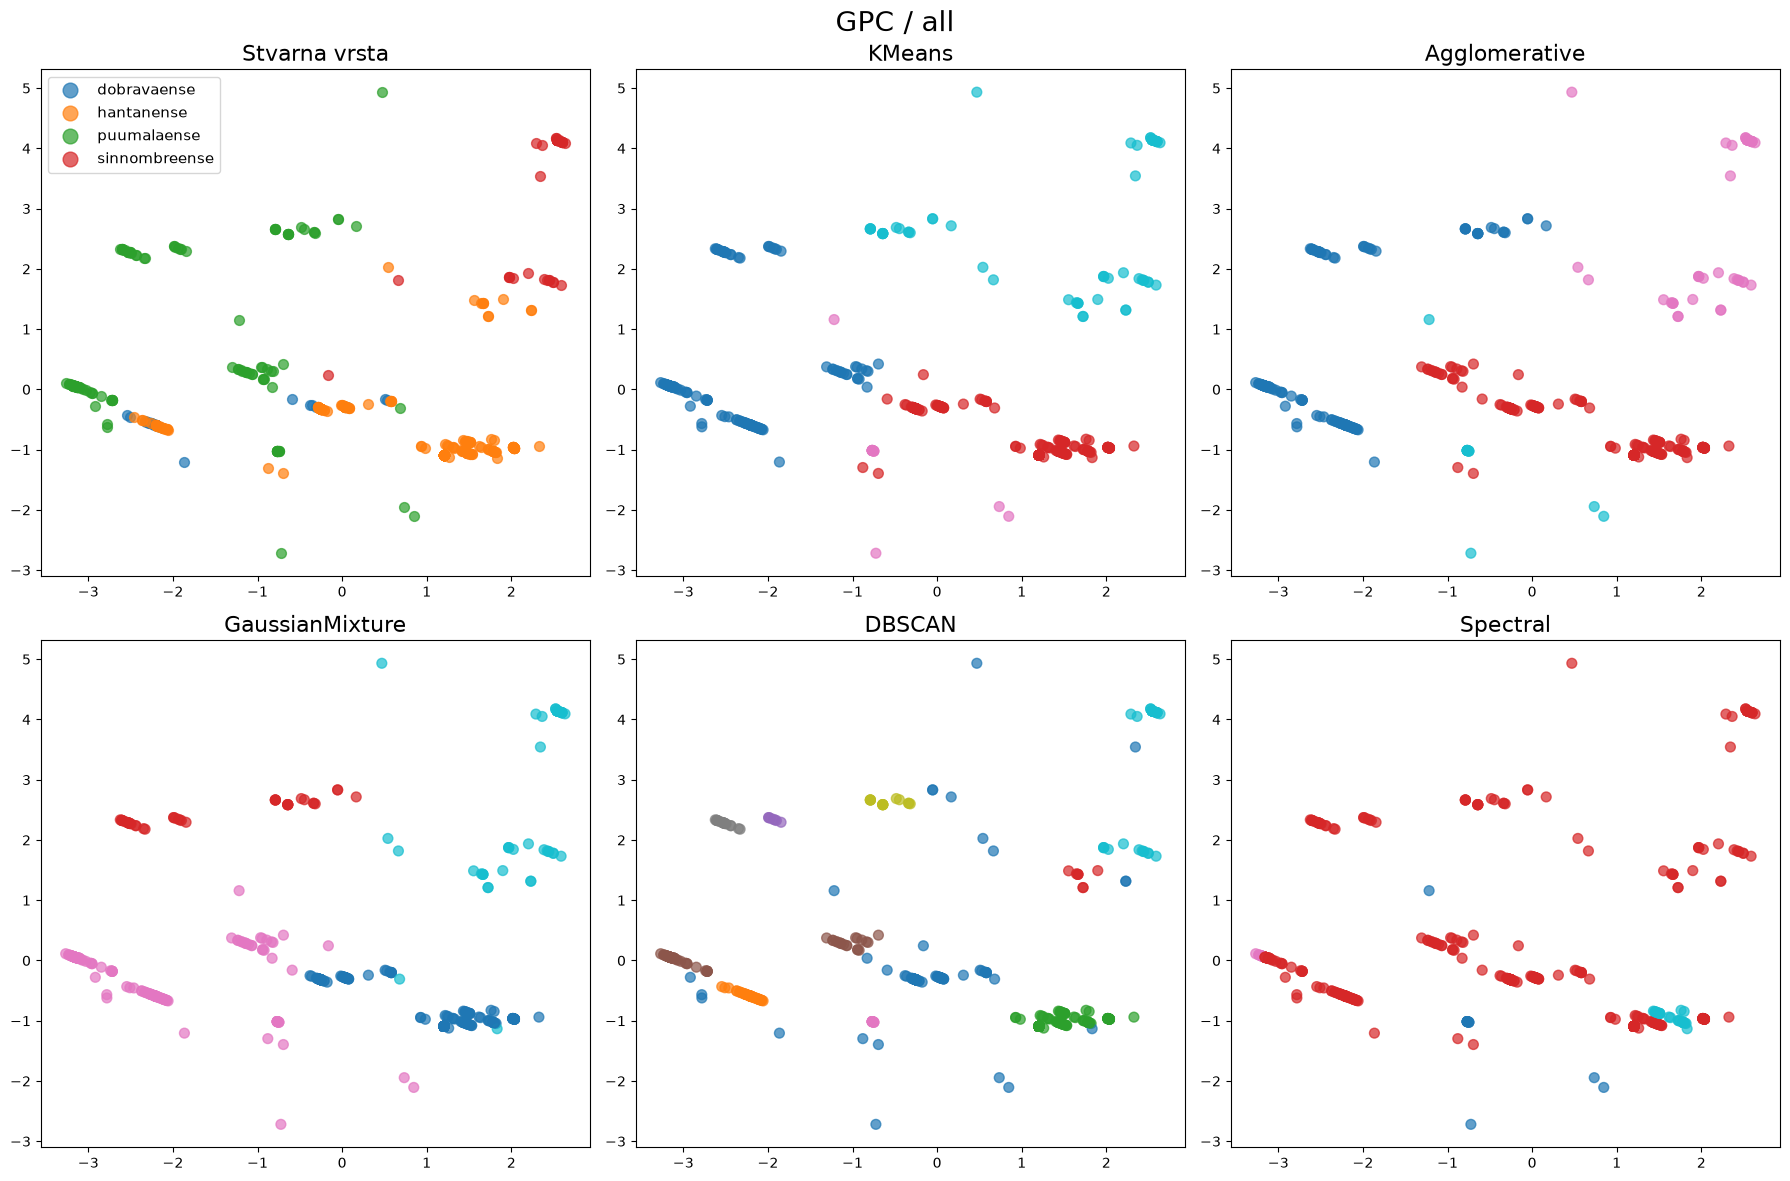

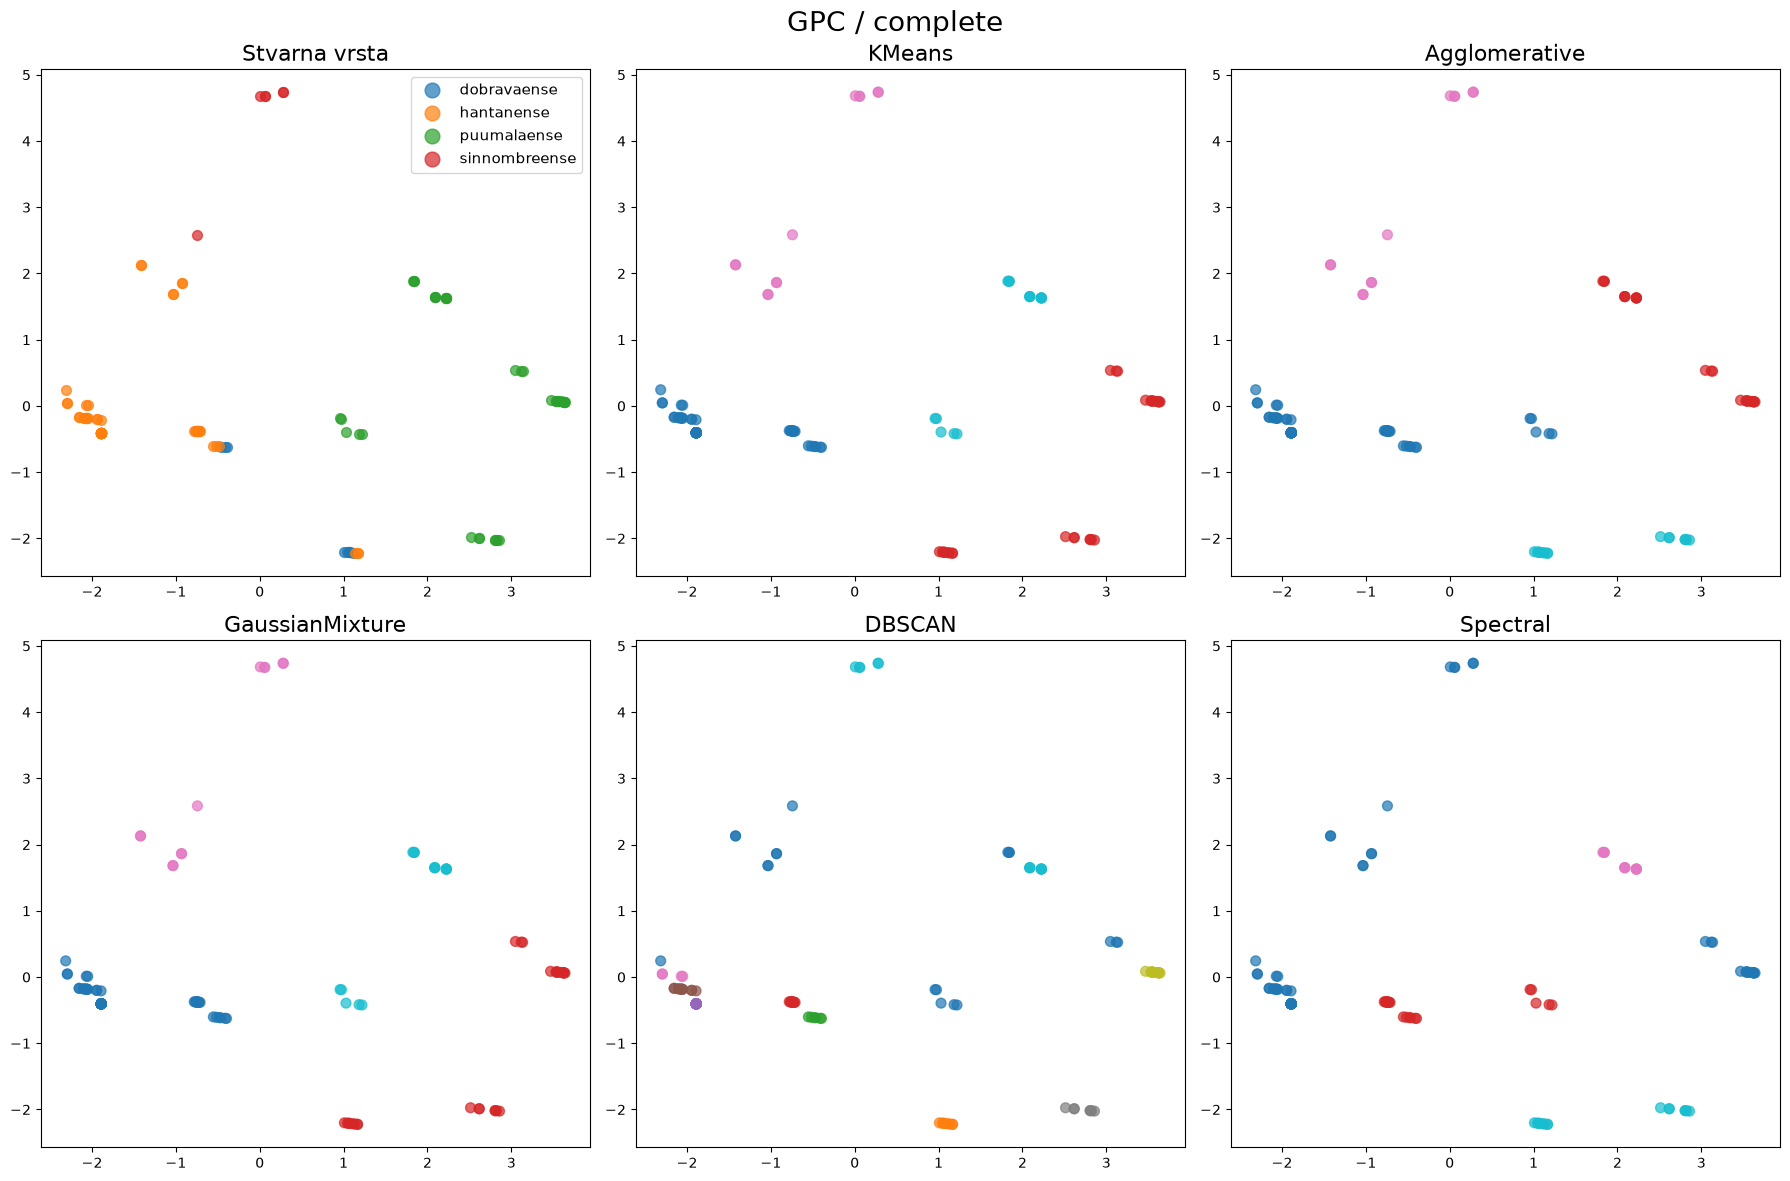

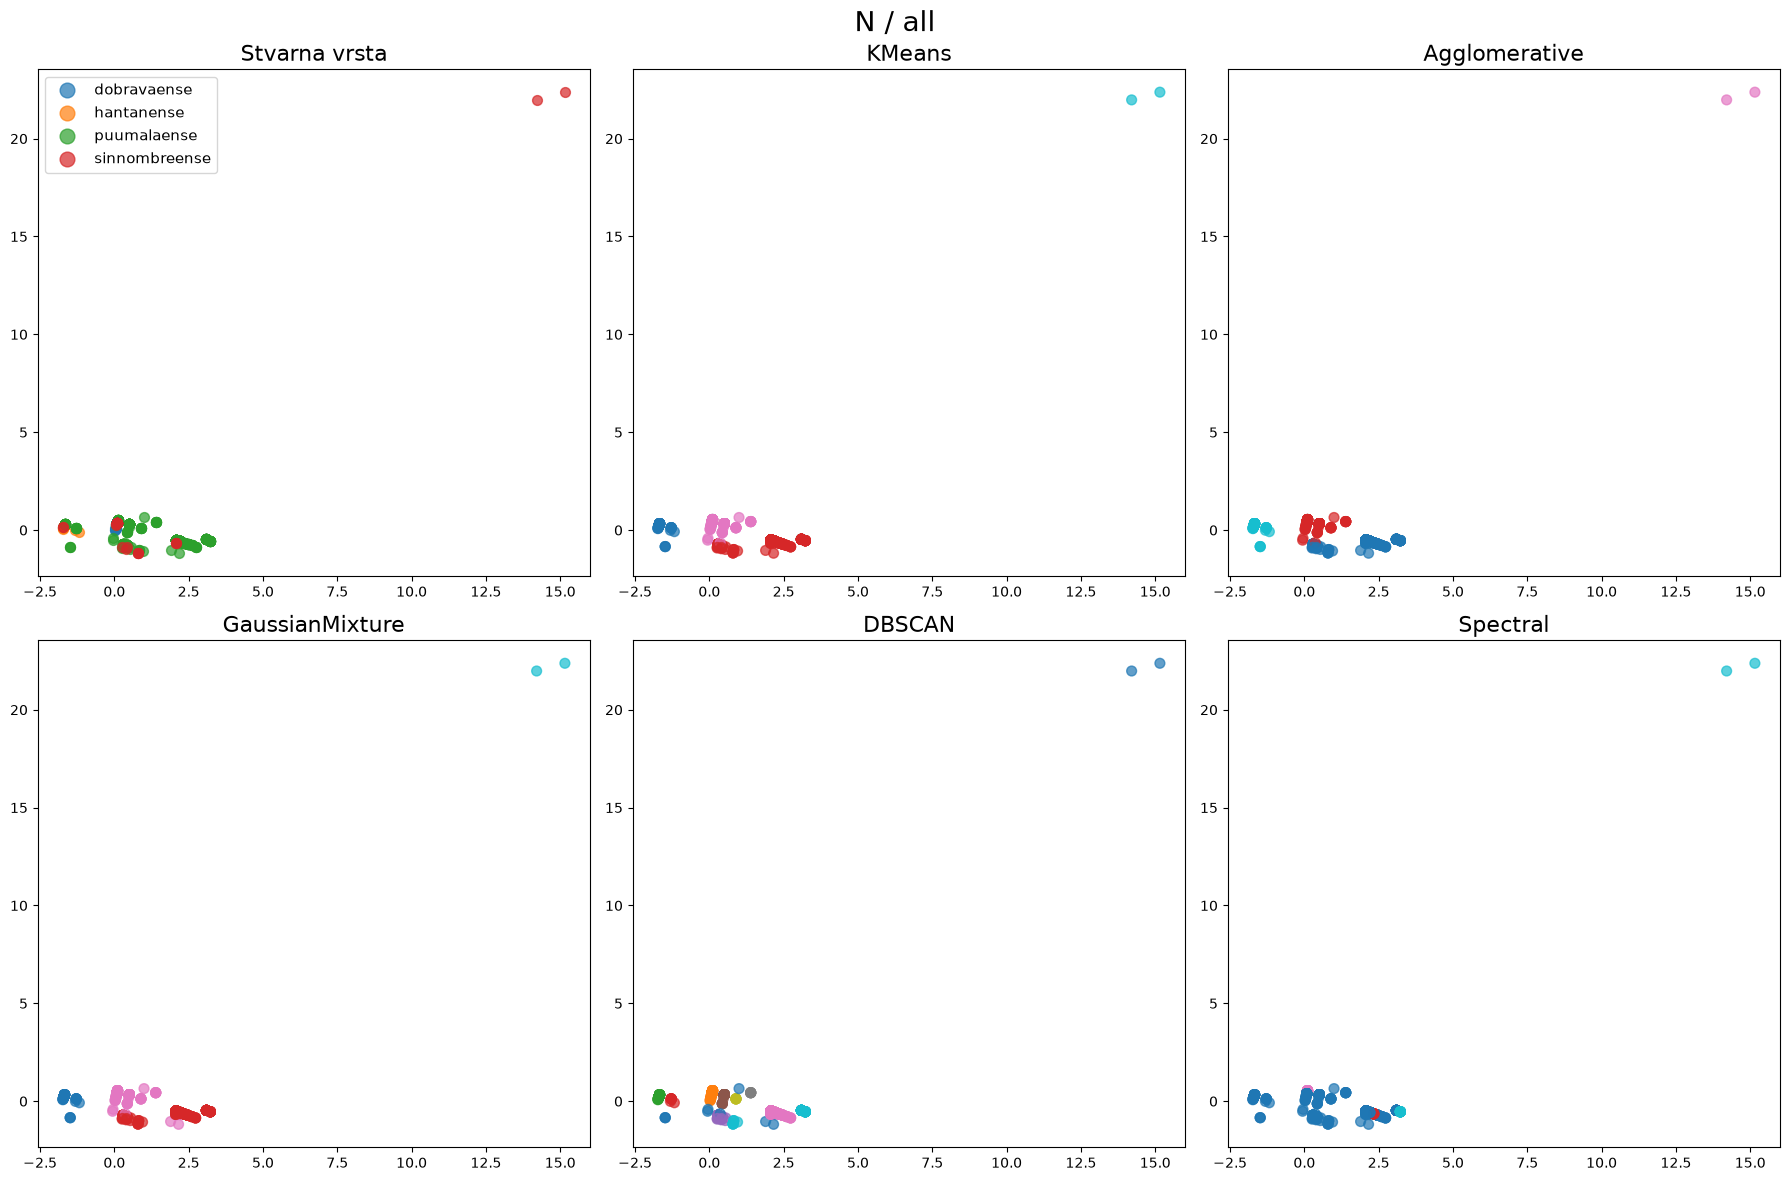

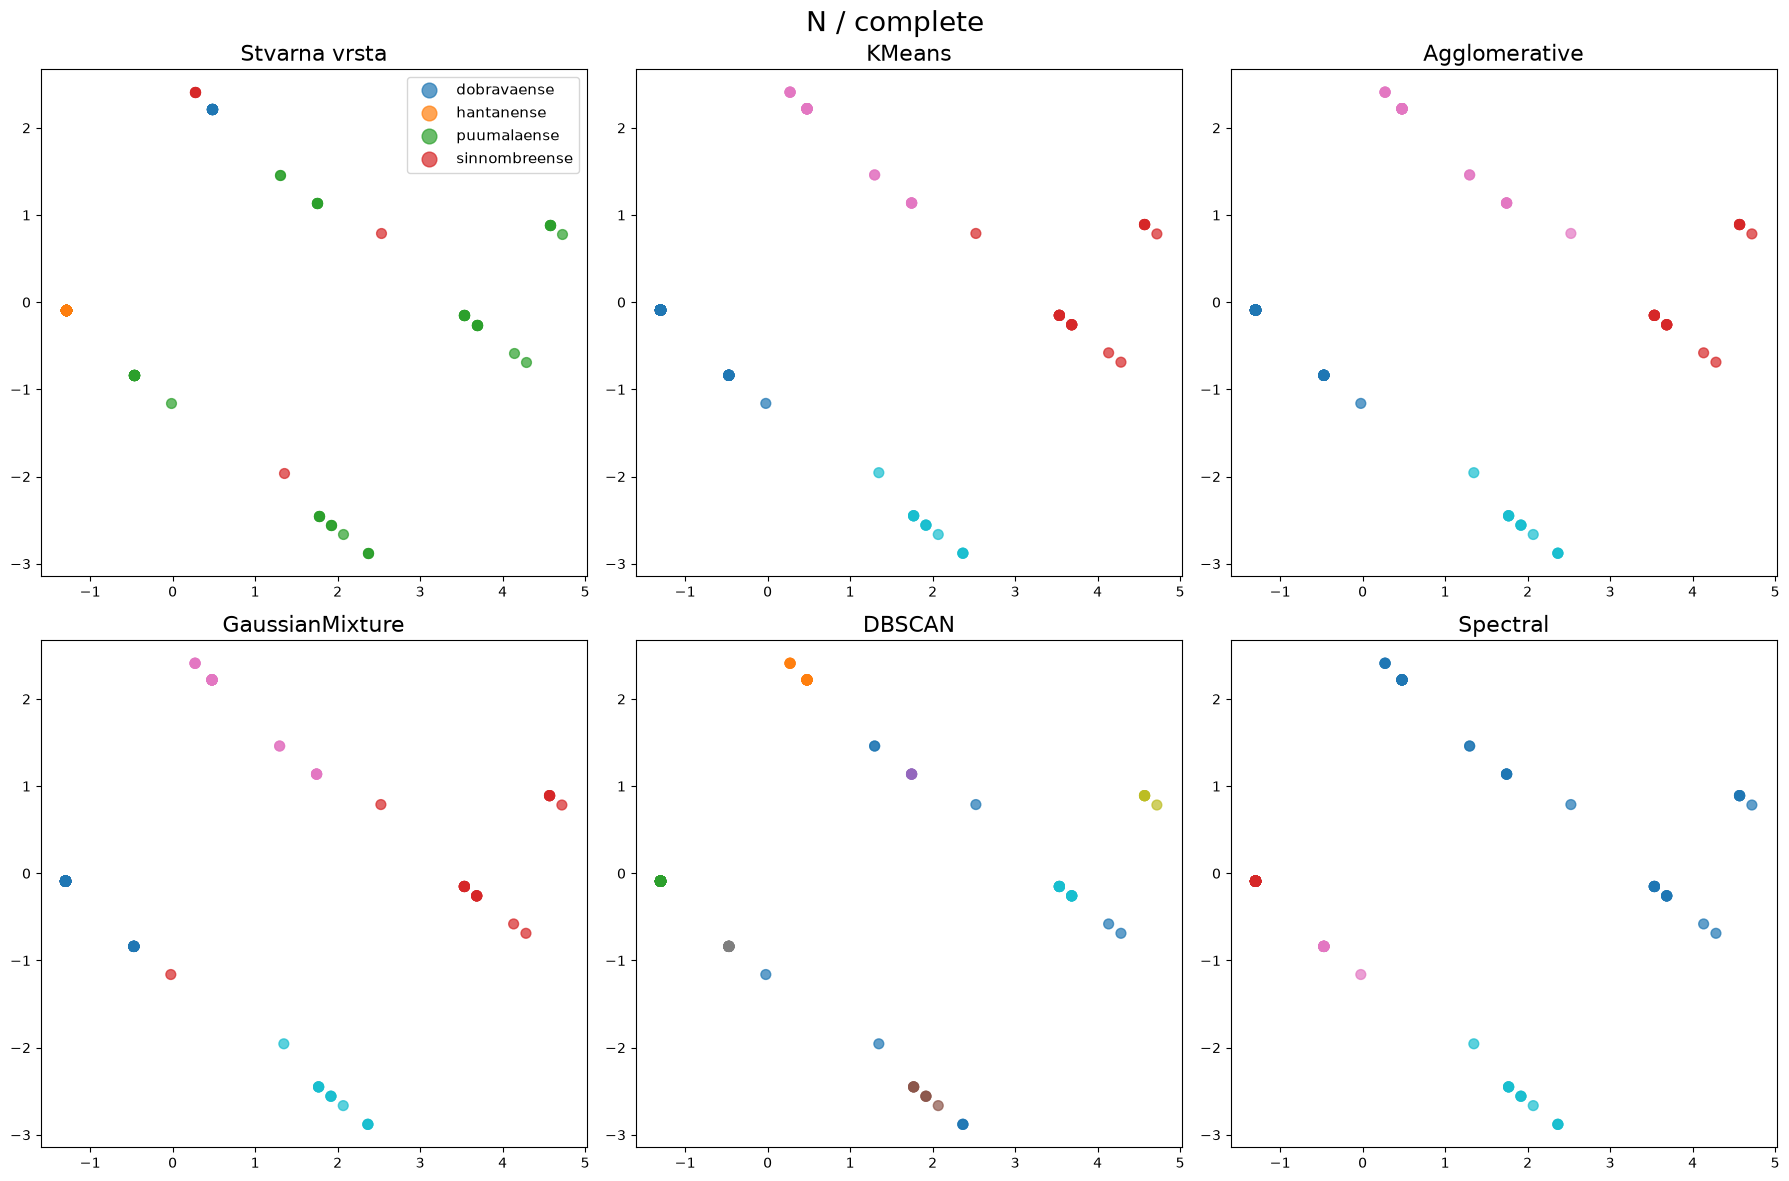

In [36]:
def plot_clustering_comparison(subset, X_pca, cluster_results, title_prefix="", save_path=None):
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X_pca)

    algorithms = list(cluster_results.keys())
    panels = [("Stvarna vrsta", None)] + [(algo, algo) for algo in algorithms]

    n_cols = 3
    n_rows = (len(panels) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
    axes = axes.flatten()

    species_list = sorted(subset["species"].unique())

    for ax, (label, algo) in zip(axes, panels):
        if algo is None:
            for sp in species_list:
                mask = subset["species"].values == sp
                ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=50, alpha=0.7, label=sp)
            ax.legend(fontsize=11, markerscale=1.5)
        else:
            labels = cluster_results[algo]
            ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=50, alpha=0.7)
        ax.set_title(label, fontsize=16)

    for ax in axes[len(panels):]:
        ax.axis("off")

    fig.suptitle(title_prefix, fontsize=20)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


for (protein, completeness), (subset, X_pca, clusters) in all_subsets.items():
    save_path = FIGURES_DIR / f"{protein}_{completeness}.png"
    plot_clustering_comparison(subset, X_pca, clusters,
                                 title_prefix=f"{protein} / {completeness}",
                                 save_path=save_path)


Na grafiku N/all vidljive su dve tačke koje drastično odskaču (gore desno), dok je sve
ostalo zbijeno u mali ugao - PCA projekcija je "zgužvana" jednim ili dva ekstremna
outlier-a. Potrebno je istražiti šta su te tačke.

In [37]:
subset_n_all, X_pca_n_all, _ = all_subsets[("N", "all")]

X_2d_check = PCA(n_components=2, random_state=42).fit_transform(X_pca_n_all)
outlier_mask = X_2d_check[:, 0] > 5

print(subset_n_all[outlier_mask][["accession", "species"] + FEATURE_COLS])


       accession        species  repeats_len_3  repeats_len_4  repeats_len_6  \
2007  AFV71290.1  sinnombreense             48             12              0   
2008  AFV71289.1  sinnombreense             51             10              0   

      repeats_len_5  repeats_len_8  seq_length  repeats_len_3_norm  \
2007              1              0        1140            0.042105   
2008              1              0        1140            0.044737   

      repeats_len_4_norm  repeats_len_6_norm  repeats_len_5_norm  \
2007            0.010526                 0.0            0.000877   
2008            0.008772                 0.0            0.000877   

      repeats_len_8_norm  
2007                 0.0  
2008                 0.0  


Dužina 1140 AK je sumnjivo blizu tipičnoj dužini GPC-a (1135-1148), ne N proteina
(~420-440). Potrebno je proveriti originalni opis i sastav sekvence pre donošenja
zaključka.

In [38]:
for rec in SeqIO.parse(DATA_RAW / "sinnombre_all.fasta", "fasta"):
    if rec.id in ("AFV71290.1", "AFV71289.1"):
        print(rec.id, "->", rec.description)


AFV71290.1 -> AFV71290.1 |nucleocapsid protein [Orthohantavirus sinnombreense]
AFV71289.1 -> AFV71289.1 |nucleocapsid protein [Orthohantavirus sinnombreense]


**Zaključak:** opis je nedvosmislen ("nucleocapsid protein"), pa greška nije u
klasifikaciji po tekstu - ovo je legitimna anomalija u samim NCBI podacima (verovatno
pogrešna anotacija ili greška u dužini submitovane sekvence). Filter dužine iz Sekcije 3
je imao samo donju granicu za N (≥400), bez gornje granice - ove dve sekvence (1140 AK)
su prošle filter iako drastično odstupaju od tipične dužine N proteina.

**Rešenje:** dodaje se gornja granica za N protein (500 AK - dovoljno iznad tipične pune
dužine ~440 da ne odseca legitimne pune sekvence, ali ispod 1140 da ukloni ovu anomaliju).
Nakon izmene, ceo pipeline (filtriranje

In [39]:
LENGTH_THRESHOLDS = {"GPC": (1000, None), "N": (400, 500)}

def is_full_length(protein_label: str, seq_length: int) -> bool:
    min_len, max_len = LENGTH_THRESHOLDS[protein_label]
    if seq_length < min_len:
        return False
    if max_len is not None and seq_length > max_len:
        return False
    return True


In [40]:
summary_df = filter_and_save()
summary_df


,species,completeness,protein,n_sequences
0,hantanense,all,N,522
1,hantanense,all,GPC,292
2,hantanense,complete,N,90
3,hantanense,complete,GPC,67
4,dobravaense,all,N,90
5,dobravaense,all,GPC,31
6,dobravaense,complete,N,18
7,dobravaense,complete,GPC,11
8,puumalaense,all,N,577
9,puumalaense,all,GPC,135


In [41]:
results_log = []

for fasta_path in sorted(DATA_FILTERED.glob("*.fasta")):
    output_path = REPEAT_OUTPUT_DIR / f"{fasta_path.stem}.txt"
    result = run_statrepeats(fasta_path, output_path)
    results_log.append({
        "file": fasta_path.name,
        "returncode": result.returncode,
        "output_exists": output_path.exists(),
        "output_size": output_path.stat().st_size if output_path.exists() else 0,
    })
    print(f"{fasta_path.name:40s} rc={result.returncode}  "
          f"out_size={results_log[-1]['output_size']}")

log_df = pd.DataFrame(results_log)
log_df


dobravaense_all_GPC.fasta                rc=0  out_size=119570
dobravaense_all_N.fasta                  rc=0  out_size=16957
dobravaense_complete_GPC.fasta           rc=0  out_size=42887
dobravaense_complete_N.fasta             rc=0  out_size=3543
hantanense_all_GPC.fasta                 rc=0  out_size=550973
hantanense_all_N.fasta                   rc=0  out_size=52299
hantanense_complete_GPC.fasta            rc=0  out_size=117617
hantanense_complete_N.fasta              rc=0  out_size=9080
puumalaense_all_GPC.fasta                rc=0  out_size=712778
puumalaense_all_N.fasta                  rc=0  out_size=365277
puumalaense_complete_GPC.fasta           rc=0  out_size=201106
puumalaense_complete_N.fasta             rc=0  out_size=28889
sinnombreense_all_GPC.fasta              rc=0  out_size=108043
sinnombreense_all_N.fasta                rc=0  out_size=15884
sinnombreense_complete_GPC.fasta         rc=0  out_size=15863
sinnombreense_complete_N.fasta           rc=0  out_size=2615


,file,returncode,output_exists,output_size
0,dobravaense_all_GPC.fasta,0,True,119570
1,dobravaense_all_N.fasta,0,True,16957
2,dobravaense_complete_GPC.fasta,0,True,42887
3,dobravaense_complete_N.fasta,0,True,3543
4,hantanense_all_GPC.fasta,0,True,550973
5,hantanense_all_N.fasta,0,True,52299
6,hantanense_complete_GPC.fasta,0,True,117617
7,hantanense_complete_N.fasta,0,True,9080
8,puumalaense_all_GPC.fasta,0,True,712778
9,puumalaense_all_N.fasta,0,True,365277


In [42]:
feature_df = build_feature_table()
feature_df = add_sequence_length(feature_df)
feature_df = add_normalized_features(feature_df)
print(feature_df.shape)
feature_df.columns.tolist()


(2032, 15)


['accession',
 'species',
 'completeness',
 'protein',
 'repeats_len_3',
 'repeats_len_4',
 'repeats_len_6',
 'repeats_len_5',
 'repeats_len_8',
 'seq_length',
 'repeats_len_3_norm',
 'repeats_len_4_norm',
 'repeats_len_6_norm',
 'repeats_len_5_norm',
 'repeats_len_8_norm']

In [43]:
n_subset = feature_df[feature_df.protein == "N"]
n_subset[n_subset.seq_length > 500][["accession", "species", "completeness", "seq_length"]]


,accession,species,completeness,seq_length


In [44]:
all_eval_results = []
all_subsets = {}

for protein in ["GPC", "N"]:
    for completeness in ["all", "complete"]:
        subset, X_pca, clusters, eval_df = run_full_pipeline(feature_df, protein, completeness)
        all_eval_results.append(eval_df)
        all_subsets[(protein, completeness)] = (subset, X_pca, clusters)
        print(f"Zavrseno: {protein}/{completeness}")

final_results = pd.concat(all_eval_results, ignore_index=True)
final_results


[GPC/all] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_8_norm']


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Zavrseno: GPC/all
[GPC/complete] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_8_norm']
Zavrseno: GPC/complete
[N/all] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_5', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_5_norm', 'repeats_len_8_norm']


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Zavrseno: N/all
[N/complete] Izbacene retke kolone (<10.0% nenula): ['repeats_len_6', 'repeats_len_5', 'repeats_len_8', 'repeats_len_6_norm', 'repeats_len_5_norm', 'repeats_len_8_norm']
Zavrseno: N/complete


/home/vladimir/PycharmProjects/hantavirus-seminarski/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,n_sequences,protein,completeness,algorithm,n_clusters_found,silhouette,ARI,NMI
0,500,GPC,all,KMeans,4,0.639345,0.610387,0.523117
1,500,GPC,all,Agglomerative,4,0.608288,0.536283,0.470777
2,500,GPC,all,GaussianMixture,4,0.601509,0.616584,0.578081
3,500,GPC,all,DBSCAN,12,0.763695,0.451234,0.570265
4,500,GPC,all,Spectral,4,-0.327983,0.010778,0.139854
5,121,GPC,complete,KMeans,4,0.602830,0.580098,0.574768
6,121,GPC,complete,Agglomerative,4,0.604330,0.530726,0.506511
7,121,GPC,complete,GaussianMixture,4,0.602830,0.580098,0.574768
8,121,GPC,complete,DBSCAN,10,0.692645,0.235858,0.485362
9,121,GPC,complete,Spectral,4,0.292335,0.210910,0.248919


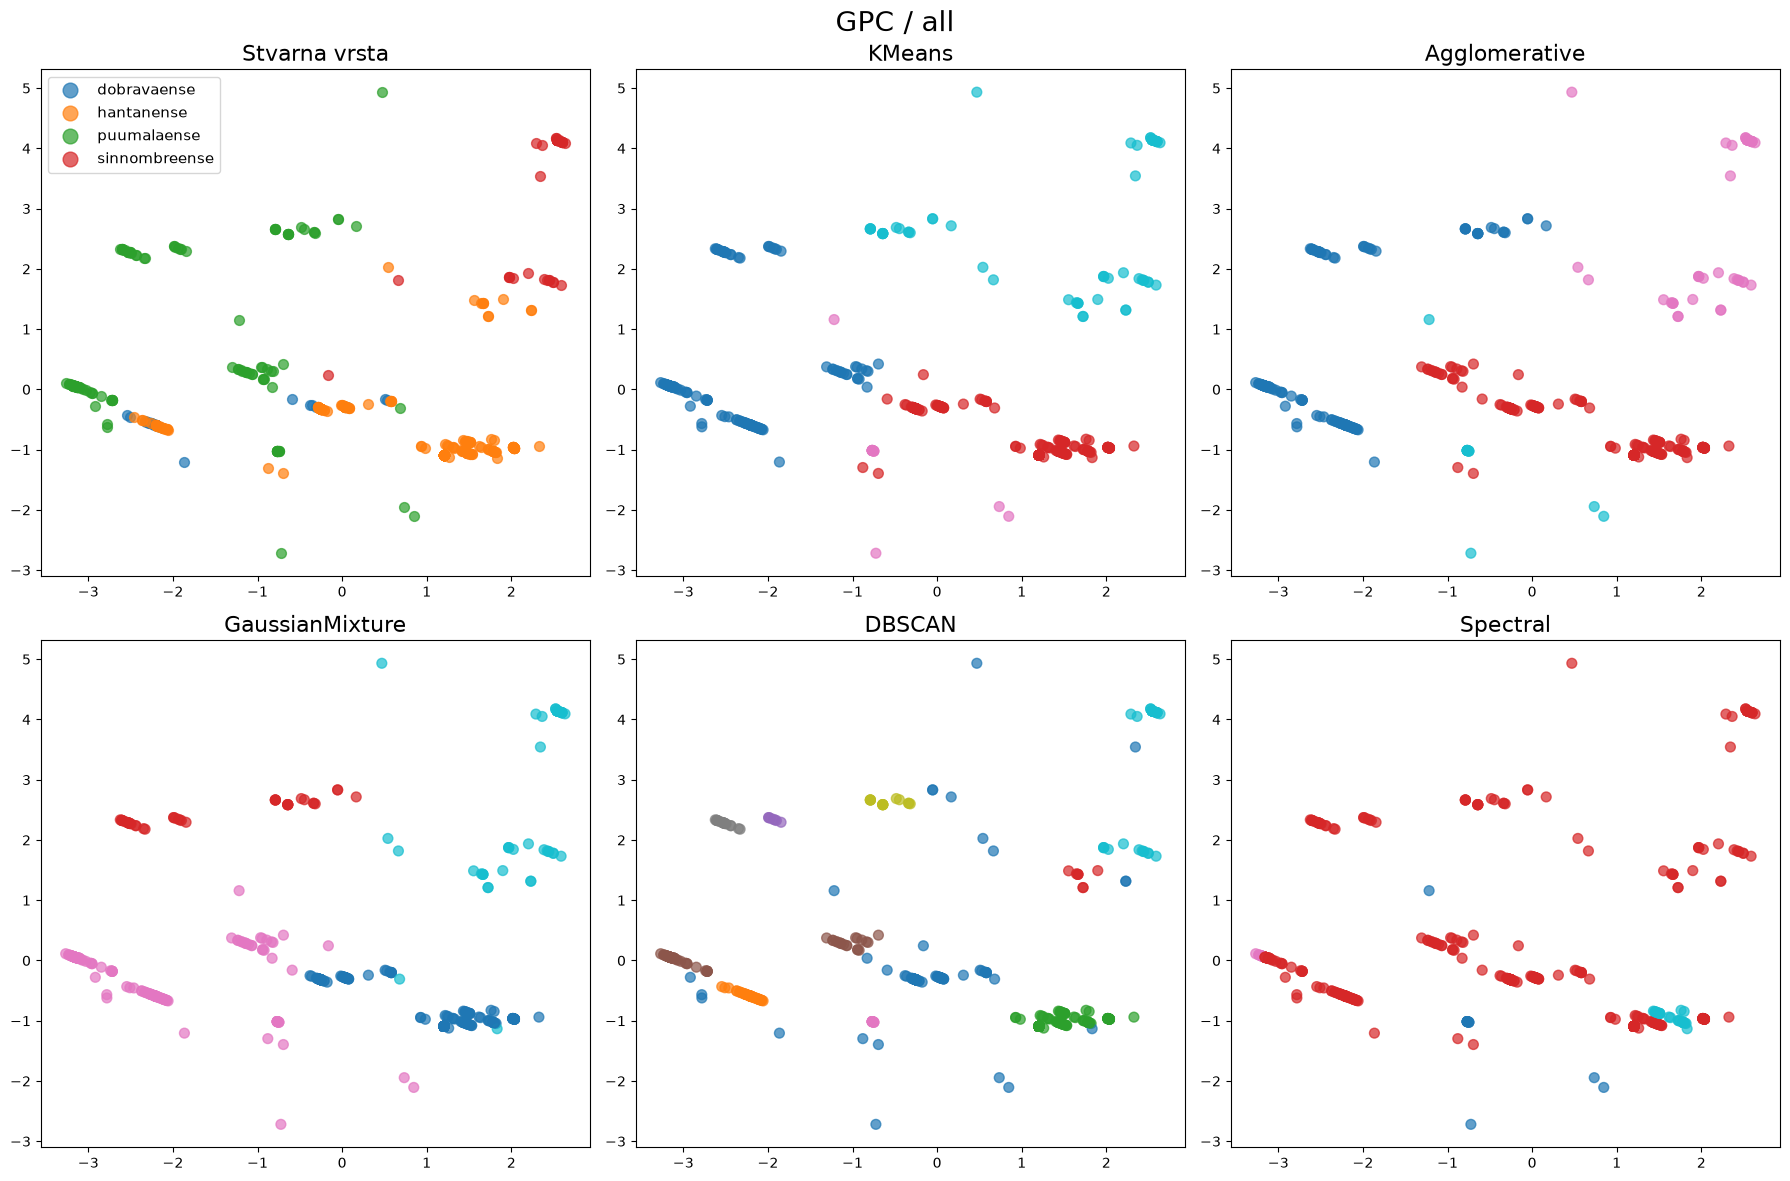

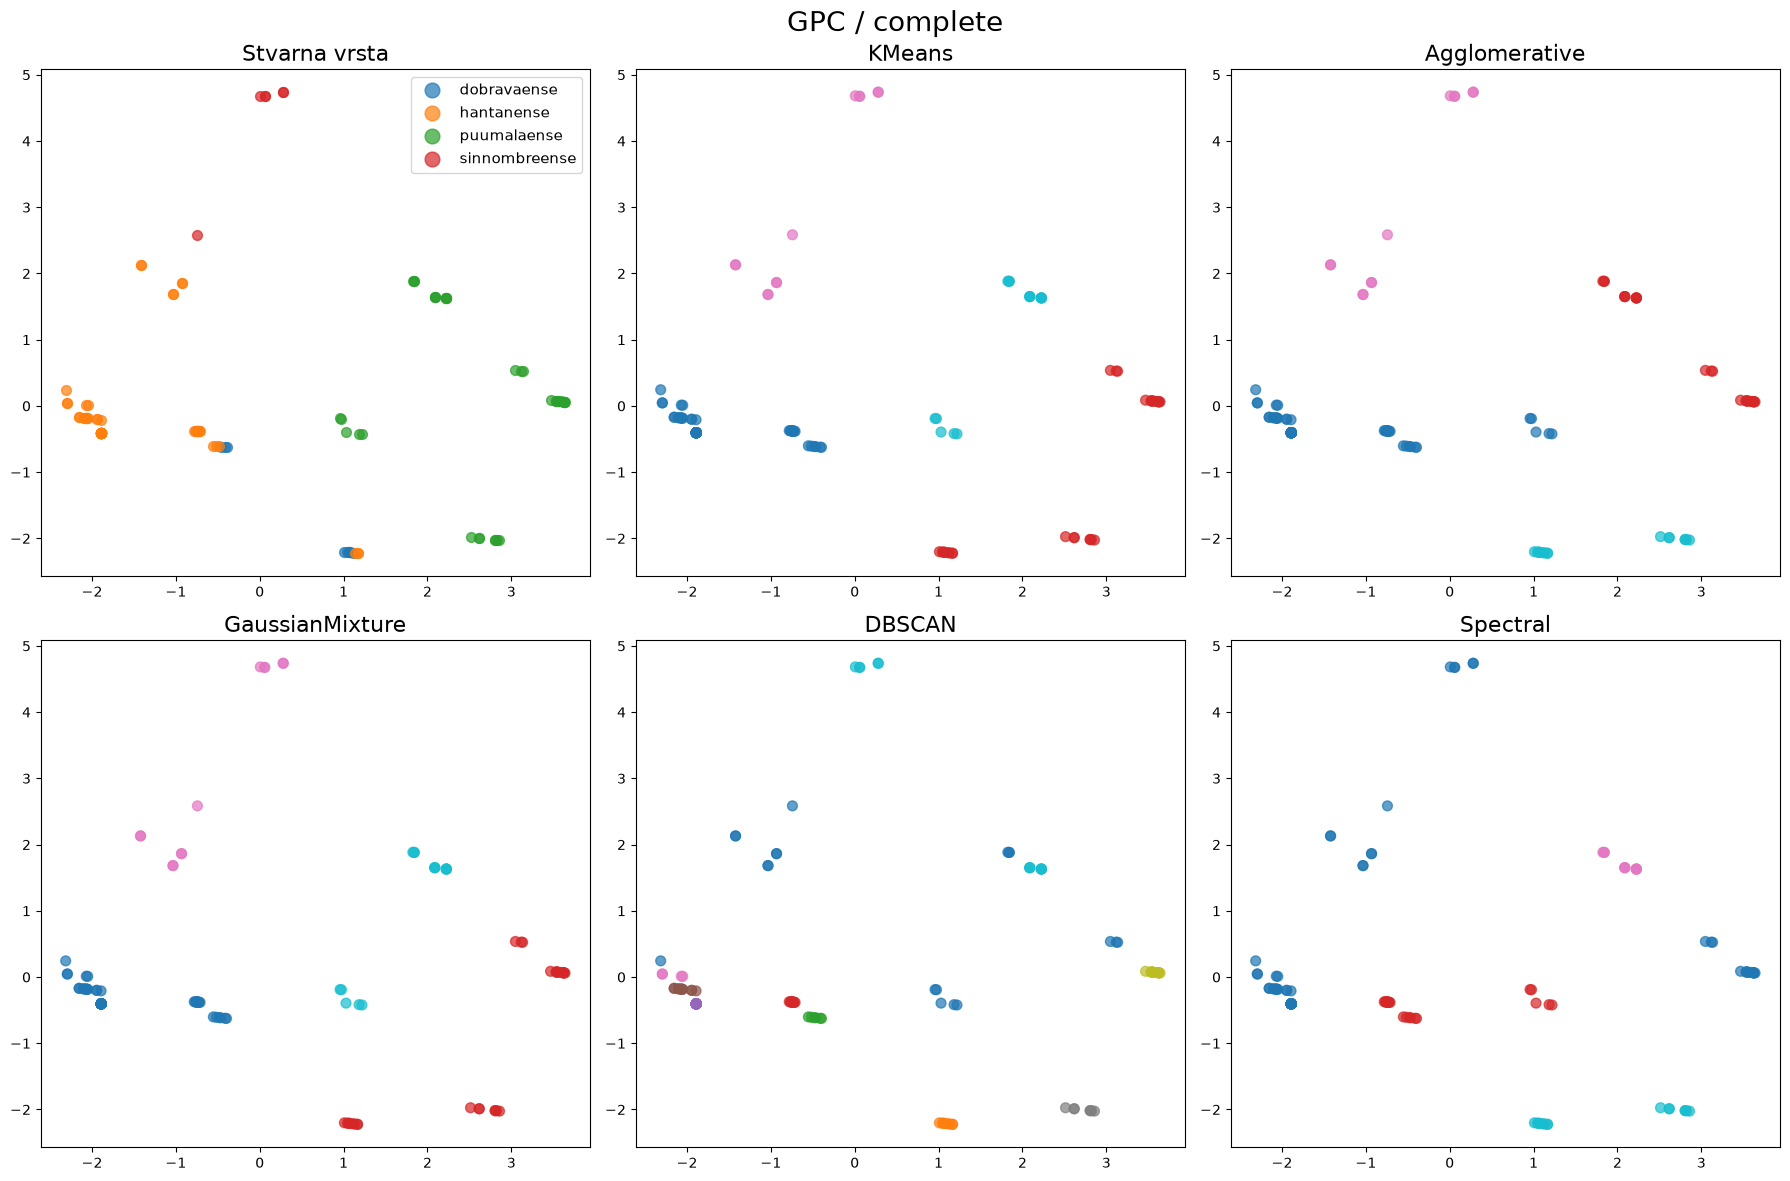

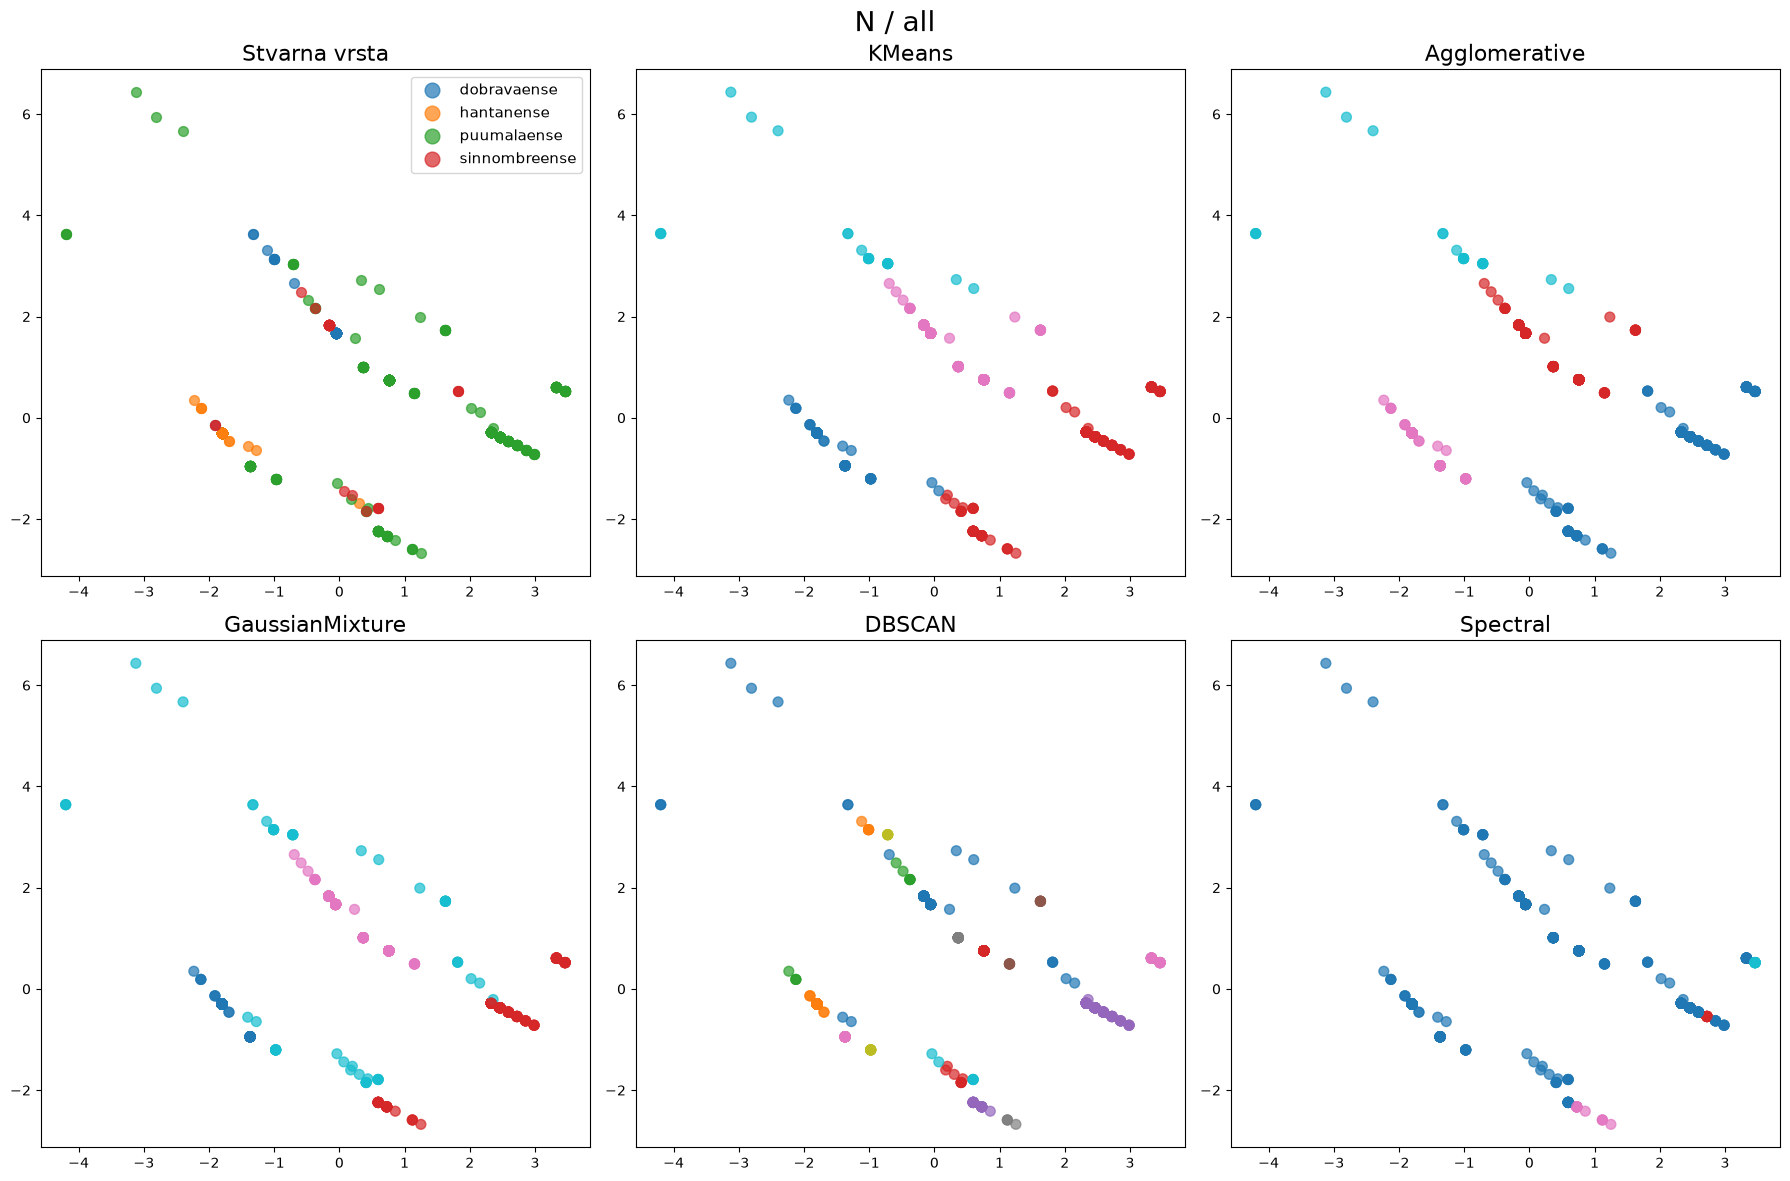

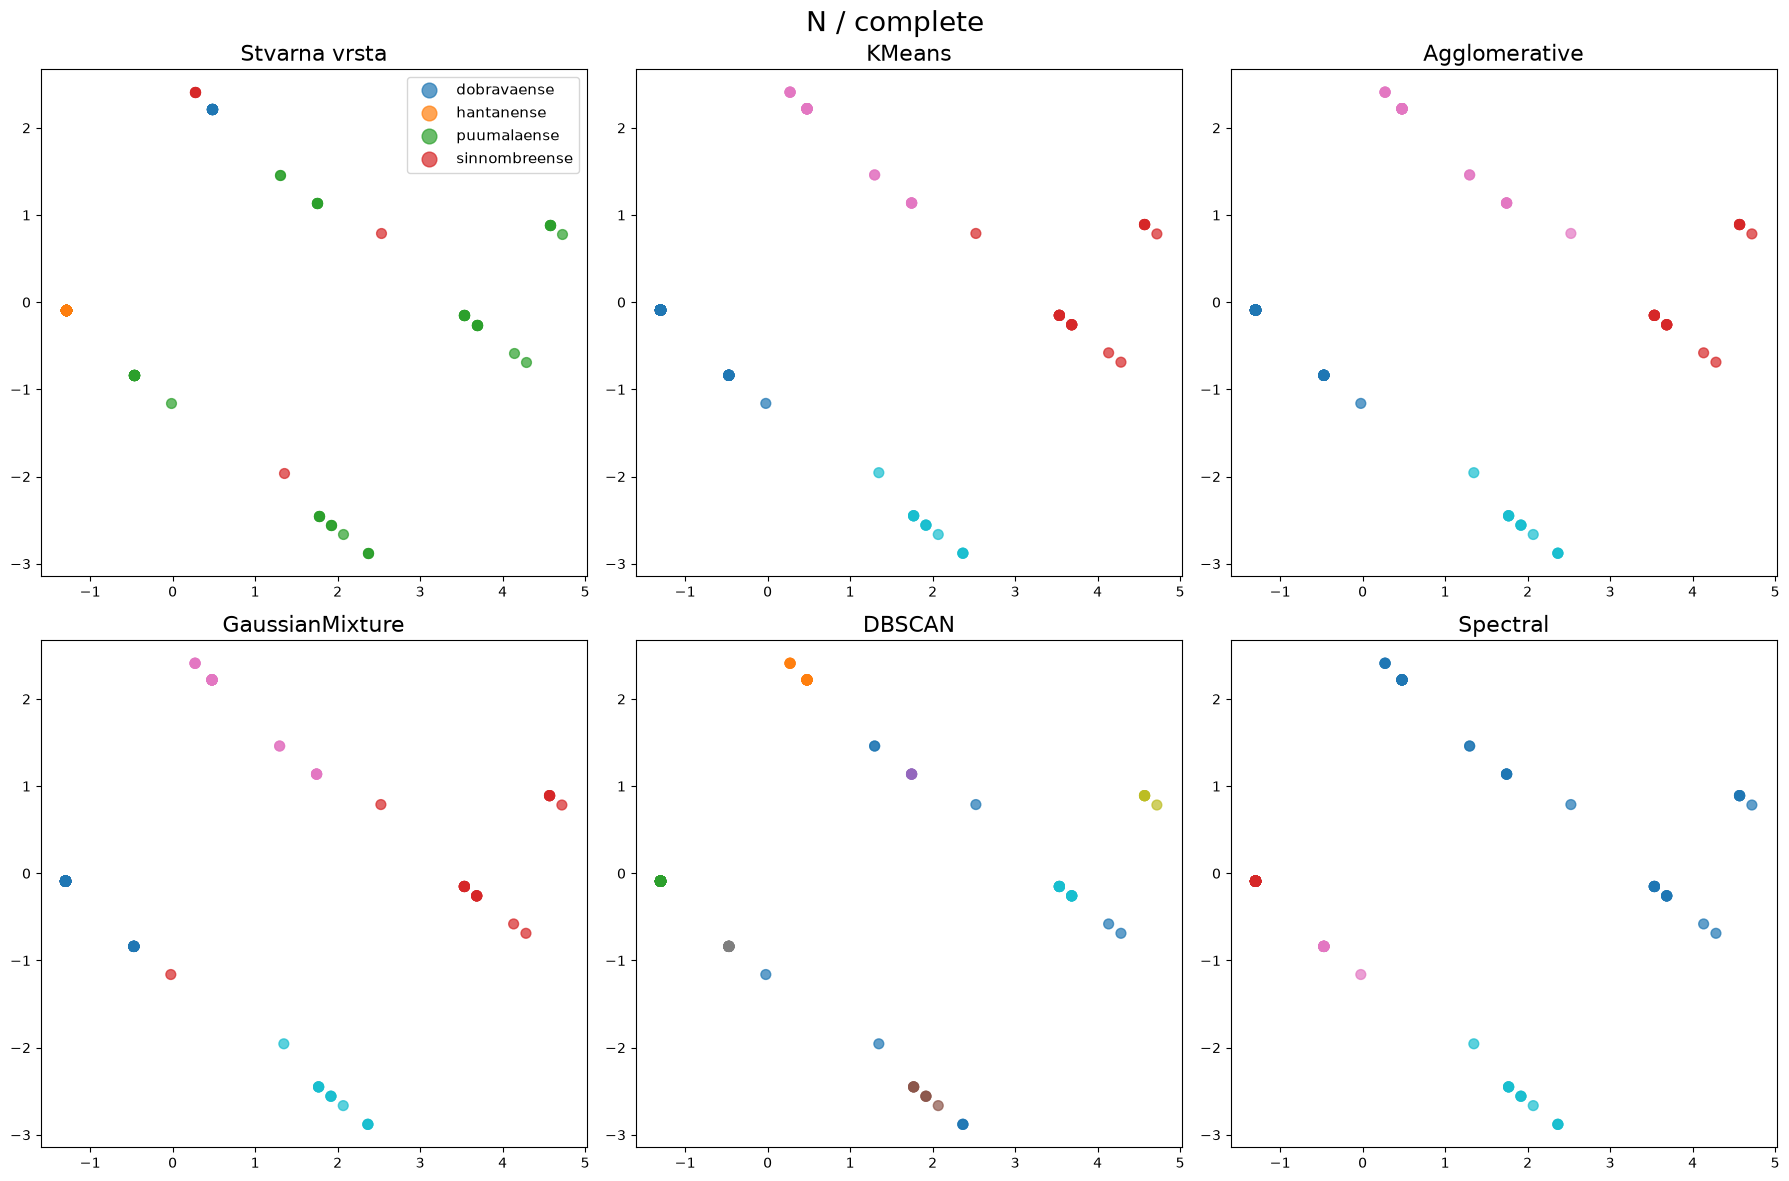

In [45]:
for (protein, completeness), (subset, X_pca, clusters) in all_subsets.items():
    save_path = FIGURES_DIR / f"{protein}_{completeness}.png"
    plot_clustering_comparison(subset, X_pca, clusters,
                                 title_prefix=f"{protein} / {completeness}",
                                 save_path=save_path)
